# **Assignmnet-3**

**Group-02**

Aashish Sanjel

Dhruv Handa

Honey Shah

Raj Jasani

## STEP 1 — Dataset Overview

### Purpose of this step  
The objective of this step is to load the dataset and conduct an initial structural inspection to understand its size, schema, and basic characteristics. This aligns with the requirement to review column names, data types, and to establish whether the dataset supports the stated project objective.

This step also formally identifies the target variable and the input features based on the project goal. No preprocessing, cleaning, or transformation is performed at this stage; the dataset is examined strictly in its raw form.

### Target and input feature definition  
Based on the project objective of forecasting **hourly 911 call volumes by department**, the target variable is not directly present in the raw dataset and will be derived in later steps.

- **Target (derived later):**  
  - Hourly call count (`y`), obtained by aggregating event-level calls by hour.

- **Primary input features:**  
  - `timeStamp`: provides the temporal reference required for hourly aggregation.  
  - `title`: contains structured text used to derive department labels (EMS, Fire, Traffic).

- **Other features:**  
  - Remaining columns (e.g., location and descriptive attributes) provide contextual information and are not required for constructing the core forecasting target.

In [101]:
import pandas as pd
import numpy as np

DATASET_PATH = "/content/911.csv"
df = pd.read_csv(DATASET_PATH)

print("DATASET SHAPE (rows, columns):", df.shape)

print("\nCOLUMN NAMES:")
print(df.columns.tolist())

print("\nDATA TYPES AND NON-NULL COUNTS:")
df.info()

print("\nFIRST 5 ROWS (sample):")
display(df.head())

print("\nTARGET AND INPUT FEATURE IDENTIFICATION (project objective aligned):")
print("- Target (derived): Hourly call count (y) after aggregating call events by hour.")
print("- Primary inputs:")
print("  * timeStamp -> temporal index for hourly aggregation")
print("  * title -> structured prefix enables department derivation (EMS/Fire/Traffic)")
print("- Context features (not required for core target construction): lat, lng, zip, twp, addr, desc, e")

DATASET SHAPE (rows, columns): (663522, 9)

COLUMN NAMES:
['lat', 'lng', 'desc', 'zip', 'title', 'timeStamp', 'twp', 'addr', 'e']

DATA TYPES AND NON-NULL COUNTS:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 663522 entries, 0 to 663521
Data columns (total 9 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   lat        663522 non-null  float64
 1   lng        663522 non-null  float64
 2   desc       663522 non-null  object 
 3   zip        583323 non-null  float64
 4   title      663522 non-null  object 
 5   timeStamp  663522 non-null  object 
 6   twp        663229 non-null  object 
 7   addr       663522 non-null  object 
 8   e          663522 non-null  int64  
dtypes: float64(3), int64(1), object(5)
memory usage: 45.6+ MB

FIRST 5 ROWS (sample):


,lat,lng,desc,zip,title,timeStamp,twp,addr,e
0,40.297876,-75.581294,REINDEER CT & DEAD END; NEW HANOVER; Station ...,19525.0,EMS: BACK PAINS/INJURY,2015-12-10 17:10:52,NEW HANOVER,REINDEER CT & DEAD END,1
1,40.258061,-75.264680,BRIAR PATH & WHITEMARSH LN; HATFIELD TOWNSHIP...,19446.0,EMS: DIABETIC EMERGENCY,2015-12-10 17:29:21,HATFIELD TOWNSHIP,BRIAR PATH & WHITEMARSH LN,1
2,40.121182,-75.351975,HAWS AVE; NORRISTOWN; 2015-12-10 @ 14:39:21-St...,19401.0,Fire: GAS-ODOR/LEAK,2015-12-10 14:39:21,NORRISTOWN,HAWS AVE,1
3,40.116153,-75.343513,AIRY ST & SWEDE ST; NORRISTOWN; Station 308A;...,19401.0,EMS: CARDIAC EMERGENCY,2015-12-10 16:47:36,NORRISTOWN,AIRY ST & SWEDE ST,1
4,40.251492,-75.603350,CHERRYWOOD CT & DEAD END; LOWER POTTSGROVE; S...,NaN,EMS: DIZZINESS,2015-12-10 16:56:52,LOWER POTTSGROVE,CHERRYWOOD CT & DEAD END,1



TARGET AND INPUT FEATURE IDENTIFICATION (project objective aligned):
- Target (derived): Hourly call count (y) after aggregating call events by hour.
- Primary inputs:
  * timeStamp -> temporal index for hourly aggregation
  * title -> structured prefix enables department derivation (EMS/Fire/Traffic)
- Context features (not required for core target construction): lat, lng, zip, twp, addr, desc, e


### Interpretation of dataset overview  

The dataset consists of **663,522 observations** and **9 variables**, indicating a large-scale collection of event-level 911 call records. Each row corresponds to an individual emergency call, while each column captures a specific attribute associated with that call, including temporal, geographic, and descriptive information. The dataset size is appropriate for time-series analysis and supports aggregation at an hourly resolution without sparsity concerns.

The column structure reveals a mix of numerical and categorical attributes. Geographic coordinates (`lat`, `lng`) are stored as numerical variables and are fully populated. The `zip` column is stored as a numerical variable but contains missing values, indicating incomplete location information for a subset of calls. Several variables (`desc`, `title`, `twp`, `addr`) are stored as object types, reflecting descriptive or categorical information.

The `timeStamp` column, which records the time at which each call occurred, is currently stored as an object rather than a datetime type. Since temporal aggregation is central to the project objective, this observation highlights the need for explicit timestamp parsing in the subsequent step.

Based on the project objective of forecasting **hourly 911 call volumes by department**, the target variable is not directly available in the raw dataset. Instead, it will be **derived** as the **hourly call count** after aggregating event-level records over time. The primary input features required for this derivation are `timeStamp`, which provides the temporal index for aggregation, and `title`, which contains structured textual prefixes (e.g., EMS, Fire) that enable department-level classification. Other variables in the dataset provide contextual information but are not required for constructing the core forecasting target.

At this stage, the dataset is intentionally left unmodified. No cleaning, filtering, or transformation is applied, ensuring that all subsequent preprocessing decisions are informed by the verified structure and characteristics observed in the raw data.


## STEP 2 — Data Types and Feature Categorization

### Purpose of this step  
The objective of this step is to categorize dataset variables into numerical, categorical, temporal, and identifier groups. This categorization supports appropriate choices for summary statistics, visualizations, and preprocessing steps in later stages of the project.

The grouping is based on both the observed data types and the functional role each feature plays in the forecasting workflow.

### Rationale  
Different feature types require different analytical treatment. Temporal variables define the time-series structure, numerical variables support quantitative summaries, categorical variables are analyzed through frequency-based methods, and identifier-like variables provide reference or grouping information rather than predictive value.


In [102]:
df["timeStamp"] = pd.to_datetime(df["timeStamp"], errors="coerce")

temporal_features = ["timeStamp"]

numerical_features = ["lat", "lng", "zip", "e"]
categorical_features = ["title", "desc", "twp"]
identifier_features = ["addr"]

feature_categories = pd.DataFrame({
    "Feature": df.columns,
    "Data_Type": [str(df[col].dtype) for col in df.columns],
    "Category": [
        "Temporal" if col in temporal_features else
        "Numerical" if col in numerical_features else
        "Categorical" if col in categorical_features else
        "Identifier" if col in identifier_features else
        "Uncategorized"
        for col in df.columns
    ]
})

feature_categories.sort_values(by=["Category", "Feature"])


,Feature,Data_Type,Category
2,desc,object,Categorical
4,title,object,Categorical
6,twp,object,Categorical
7,addr,object,Identifier
8,e,int64,Numerical
0,lat,float64,Numerical
1,lng,float64,Numerical
3,zip,float64,Numerical
5,timeStamp,datetime64[ns],Temporal


In [103]:
print("\nNOTES ON FEATURE CATEGORIZATION (justification for borderline cases):")
print("- zip is stored as numeric but represents a location code; it may be treated as categorical or excluded later depending on modeling scope.")
print("- desc has extremely high cardinality and functions like a near-unique descriptor; it is not suitable as a standard categorical predictor.")
print("- addr is treated as identifier-like (location reference), not a direct predictive feature in raw form.")


NOTES ON FEATURE CATEGORIZATION (justification for borderline cases):
- zip is stored as numeric but represents a location code; it may be treated as categorical or excluded later depending on modeling scope.
- desc has extremely high cardinality and functions like a near-unique descriptor; it is not suitable as a standard categorical predictor.
- addr is treated as identifier-like (location reference), not a direct predictive feature in raw form.


### Interpretation of data types and feature categorization  

The dataset variables were grouped into numerical, categorical, temporal, and identifier categories based on both their observed data types and their functional role in the forecasting workflow. This categorization supports appropriate selection of summary statistics, visualizations, and preprocessing strategies in later stages of the analysis.

The `timeStamp` variable is classified as a **temporal feature** and is stored in `datetime64[ns]` format. This confirms that it can serve as a valid time index for aggregating event-level records into hourly intervals, which is essential for constructing the forecasting target.

Numerical features include geographic coordinates (`lat`, `lng`), the `zip` code, and the indicator variable `e`. These variables support quantitative summaries but are not directly required for constructing the hourly call volume target. The `zip` variable, while numeric in storage, represents a location code and will be treated cautiously in subsequent steps due to missing values and its categorical nature in practice.

Categorical features include `title`, `twp`, and `desc`. Among these, `title` plays a critical role in the project, as it contains structured prefixes that enable derivation of operational departments (EMS, Fire, Traffic). Other categorical variables provide contextual information but are not required for the core forecasting objective.

The `addr` variable is classified as an **identifier**, as it uniquely describes call locations but does not provide predictive value in its raw form for time-series forecasting.

This feature categorization establishes a clear structural understanding of the dataset and provides a principled basis for subsequent preprocessing, aggregation, and modeling decisions.


## STEP 3 — Missing Data and Quality Assessment

### Purpose of this step  
The objective of this step is to assess the quality and completeness of the dataset prior to feature derivation and aggregation. In time-series forecasting, unresolved data quality issues—such as missing values, duplicate records, invalid ranges, or inconsistent formats—can distort aggregated counts and lead to biased or misleading results.

This step systematically examines missing values across all variables, quantifies the proportion of missing data, and evaluates potential data quality issues including duplicate records, invalid numerical ranges, and format inconsistencies. Based on this assessment, informed decisions can later be made regarding whether specific features should be retained, excluded, or handled cautiously in subsequent preprocessing steps.

At this stage, the focus is on **assessment rather than transformation**. No imputation or exclusion is finalized here unless required to correct invalid or inconsistent data representations.

### Rationale  
The forecasting target in this project is derived through aggregation of event-level records into hourly call volumes. Therefore, it is essential to ensure that missingness or data irregularities do not compromise temporal integrity or bias department-wise call counts. Conducting a structured data quality assessment before aggregation improves transparency, supports reproducibility, and aligns directly with the project evaluation rubric.


In [104]:
n_rows, n_cols = df.shape
print("STEP 3 — MISSING DATA AND QUALITY ASSESSMENT")
print("=" * 80)
print(f"Dataset size: {n_rows:,} rows × {n_cols} columns\n")

print("3.1 Missing values summary (counts and percentages):")
missing_counts = df.isna().sum()
missing_percent = (missing_counts / n_rows) * 100

missing_summary = (
    pd.DataFrame({"Missing_Count": missing_counts, "Missing_Percentage": missing_percent})
    .sort_values("Missing_Count", ascending=False)
)

missing_only = missing_summary[missing_summary["Missing_Count"] > 0]
if len(missing_only) > 0:
    display(missing_only)
    print(f"\nColumns with missing values: {missing_only.index.tolist()}\n")
else:
    print("No missing values detected in any column.\n")

print("3.2 Missingness pattern check (impact-relevant fields):")
rows_with_any_missing = df.isna().any(axis=1).sum()
print(f"Rows with at least one missing value (any column): {rows_with_any_missing:,}")

if "zip" in df.columns:
    print(f"Rows with missing ZIP: {df['zip'].isna().sum():,} ({(df['zip'].isna().mean()*100):.2f}%)")
if "twp" in df.columns:
    print(f"Rows with missing TWP: {df['twp'].isna().sum():,} ({(df['twp'].isna().mean()*100):.2f}%)")
print()

print("3.3 Duplicate record check (and correction if needed):")
duplicate_count = df.duplicated().sum()
print(f"Duplicate rows detected BEFORE correction: {duplicate_count:,} ({(duplicate_count/n_rows)*100:.4f}%)")

if duplicate_count > 0:
    df = df.drop_duplicates().copy()
    print(f"Action taken: Duplicate rows removed. New dataset size: {df.shape[0]:,} rows.")
else:
    print("Action taken: No duplicates found; no removal required.")
print()

print("3.4 Invalid range checks (geographic coordinates):")
lat_min, lat_max = df["lat"].min(), df["lat"].max()
lng_min, lng_max = df["lng"].min(), df["lng"].max()
print(f"Latitude range observed:  {lat_min:.6f} to {lat_max:.6f}")
print(f"Longitude range observed: {lng_min:.6f} to {lng_max:.6f}")

invalid_lat = ((df["lat"] < -90) | (df["lat"] > 90)).sum()
invalid_lng = ((df["lng"] < -180) | (df["lng"] > 180)).sum()
print(f"Rows with invalid latitude (outside [-90, 90]): {invalid_lat:,}")
print(f"Rows with invalid longitude (outside [-180, 180]): {invalid_lng:,}")
print()

print("3.5 Inconsistent format checks:")
if "zip" in df.columns:
    zip_dtype = df["zip"].dtype
    sample_zip = df["zip"].dropna().head(3).tolist()
    print(f"ZIP dtype observed: {zip_dtype} (often float due to missing values). Sample non-null ZIP values: {sample_zip}")
else:
    print("ZIP column not present; skipped.")

invalid_timestamps = df["timeStamp"].isna().sum()
print(f"Rows with invalid/unparsed timestamps: {invalid_timestamps:,}")
print()

print("3.6 Handling decisions (objective-linked):")
print("- Missing ZIP/TWP: retained as missing (no imputation), because the forecasting target is derived from timeStamp + call counts, not location completeness.")
print("- Duplicate rows: removed (to prevent inflated call counts during hourly aggregation).")
print("- Geographic ranges: globally valid; anomalous locations are flagged for awareness but retained since the objective is call-volume forecasting rather than geospatial modeling.")
print("- Timestamp validity: fully valid; suitable for hourly aggregation.")

STEP 3 — MISSING DATA AND QUALITY ASSESSMENT
Dataset size: 663,522 rows × 9 columns

3.1 Missing values summary (counts and percentages):


,Missing_Count,Missing_Percentage
zip,80199,12.086864
twp,293,0.044158



Columns with missing values: ['zip', 'twp']

3.2 Missingness pattern check (impact-relevant fields):
Rows with at least one missing value (any column): 80,323
Rows with missing ZIP: 80,199 (12.09%)
Rows with missing TWP: 293 (0.04%)

3.3 Duplicate record check (and correction if needed):
Duplicate rows detected BEFORE correction: 240 (0.0362%)
Action taken: Duplicate rows removed. New dataset size: 663,282 rows.

3.4 Invalid range checks (geographic coordinates):
Latitude range observed:  0.000000 to 51.335390
Longitude range observed: -119.698206 to 87.854975
Rows with invalid latitude (outside [-90, 90]): 0
Rows with invalid longitude (outside [-180, 180]): 0

3.5 Inconsistent format checks:
ZIP dtype observed: float64 (often float due to missing values). Sample non-null ZIP values: [19525.0, 19446.0, 19401.0]
Rows with invalid/unparsed timestamps: 0

3.6 Handling decisions (objective-linked):
- Missing ZIP/TWP: retained as missing (no imputation), because the forecasting target is 

### Interpretation of missing data and quality assessment  

The missing data analysis shows that missingness is limited to two variables: `zip` and `twp`. The `zip` column contains **80,199 missing values**, representing approximately **12.09%** of the dataset, while the `twp` column contains **293 missing values**, accounting for **0.04%** of all records. All other variables, including `timeStamp`, `title`, and the geographic coordinates (`lat`, `lng`), are fully populated.

An examination of missingness patterns indicates that **80,323 records** contain at least one missing value across the dataset. The majority of this missingness is attributable to the `zip` field, suggesting that incomplete postal code information is a common data limitation rather than a systematic issue affecting multiple critical variables simultaneously. Missing values in `twp` are minimal and do not materially affect the dataset at scale.

The duplicate record check identified **240 duplicate rows**, representing approximately **0.036%** of the dataset. This indicates that duplication is extremely limited and does not pose a significant risk to the integrity of aggregated call counts. These duplicates are flagged for consideration but do not necessitate immediate corrective action at this assessment stage.

Geographic range validation shows that latitude values range from **0.00 to 51.34**, and longitude values range from **−119.70 to 87.85**. All latitude and longitude values fall within globally valid bounds (−90 to 90 for latitude and −180 to 180 for longitude), and no records violate these constraints. While the observed ranges extend beyond the expected local geographic area, they do not represent invalid numeric values and therefore do not indicate data corruption.

Timestamp validation confirms that there are **no invalid or unparsed timestamps** following datetime conversion. The `timeStamp` field is fully valid and suitable for time-based aggregation, ensuring that temporal integrity is preserved for subsequent hourly analysis.

Overall, the data quality assessment indicates that the dataset is structurally sound for the project objective. Missingness is confined to non-critical location-related variables, duplicate records are minimal, numeric ranges are valid, and temporal data is complete. As a result, no immediate imputation or exclusion is required at this stage, and the dataset can safely proceed to feature derivation and aggregation steps without introducing bias or misleading results.


## STEP 4 — Descriptive Statistics

### Purpose of this step  
The objective of this step is to compute descriptive statistics in order to understand the distributional characteristics of the dataset prior to modeling. This includes examining central tendency, spread, and distribution shape for numerical variables, as well as frequency distributions for categorical variables.

Descriptive statistics provide an empirical summary of the data and help assess whether variables are well-behaved, imbalanced, or dominated by a small number of categories. This step does not involve feature engineering or modeling; it is intended solely to describe the observed data.

### Rationale  
Understanding the distribution of numerical variables helps identify skewness, variability, and potential anomalies that may influence downstream analysis. Similarly, frequency counts for categorical variables reveal class balance and dominant categories, which is particularly important when aggregating data by department and time. Performing this step before aggregation ensures that later transformations are informed by the underlying data characteristics.


In [105]:
print("STEP 4 — DESCRIPTIVE STATISTICS")
print("=" * 80)
print("\n4.1 Numerical variable summary statistics (central tendency + spread):")

numerical_vars = ["lat", "lng", "zip", "e"]
numerical_vars = [col for col in numerical_vars if col in df.columns]

numerical_summary = df[numerical_vars].describe()
display(numerical_summary)

print("\n4.1.1 Distribution shape (skewness) for numerical variables:")

skewness = df[numerical_vars].skew(numeric_only=True)
display(skewness)

print("\n4.2 Categorical variable frequency distributions (dominant categories + class balance):")

categorical_vars = ["title", "twp", "desc"]
categorical_vars = [col for col in categorical_vars if col in df.columns]

for col in categorical_vars:
    print(f"\n--- {col} ---")

    freq = df[col].value_counts(dropna=False)
    print("Top 10 categories (counts):")
    display(freq.head(10))

    freq_pct = (df[col].value_counts(dropna=False, normalize=True) * 100).round(2)
    print("Top 10 categories (percentages):")
    display(freq_pct.head(10))

    print(f"Total unique categories in '{col}' (excluding NaN): {df[col].nunique(dropna=True)}")
    print(f"Missing values in '{col}': {df[col].isna().sum():,}")


STEP 4 — DESCRIPTIVE STATISTICS

4.1 Numerical variable summary statistics (central tendency + spread):


,lat,lng,zip,e
count,663282.000000,663282.000000,583117.000000,663282.0
mean,40.158166,-75.300103,19236.056546,1.0
std,0.220676,1.673185,298.232804,0.0
min,0.000000,-119.698206,1104.000000,1.0
25%,40.100344,-75.392735,19038.000000,1.0
50%,40.143927,-75.305143,19401.000000,1.0
75%,40.229008,-75.211865,19446.000000,1.0
max,51.335390,87.854975,77316.000000,1.0



4.1.1 Distribution shape (skewness) for numerical variables:


,0
lat,-63.131698
lng,94.395861
zip,8.686822
e,0.000000



4.2 Categorical variable frequency distributions (dominant categories + class balance):

--- title ---
Top 10 categories (counts):


...

Total unique categories in 'twp' (excluding NaN): 68
Missing values in 'twp': 293

--- desc ---
Top 10 categories (counts):


,count
desc,
HAVERFORD STATION RD & W MONTGOMERY AVE; LOWER MERION; 2020-07-29 @ 15:52:46;,1
REINDEER CT & DEAD END; NEW HANOVER; Station 332; 2015-12-10 @ 17:10:52;,1
COLONY DR & PAWLINGS RD; LOWER PROVIDENCE; Station 322A; 2020-07-29 @ 15:29:01;,1
MAIN ST & JEFFERSON AVE; WEST NORRITON; 2020-07-29 @ 15:25:36;,1
WASHINGTON ST & W 3RD ST; PENNSBURG; Station 369; 2020-07-29 @ 15:23:13;,1
CHATHAM CT & DEERFIELD DR; FRANCONIA; Station 339; 2020-07-29 @ 15:22:23;,1
1ST AVE & GERMANTOWN PIKE; WHITEMARSH; 2020-07-29 @ 15:20:58-Station:STA29;,1
NEW HOPE ST & LINDA LN; NORRISTOWN; 2020-07-29 @ 15:13:44;,1
JOSEPH RD & MARIETTA DR; HORSHAM; Station 352A; 2020-07-29 @ 15:14:29;,1


Top 10 categories (percentages):


,proportion
desc,
HAVERFORD STATION RD & W MONTGOMERY AVE; LOWER MERION; 2020-07-29 @ 15:52:46;,0.0
REINDEER CT & DEAD END; NEW HANOVER; Station 332; 2015-12-10 @ 17:10:52;,0.0
COLONY DR & PAWLINGS RD; LOWER PROVIDENCE; Station 322A; 2020-07-29 @ 15:29:01;,0.0
MAIN ST & JEFFERSON AVE; WEST NORRITON; 2020-07-29 @ 15:25:36;,0.0
WASHINGTON ST & W 3RD ST; PENNSBURG; Station 369; 2020-07-29 @ 15:23:13;,0.0
CHATHAM CT & DEERFIELD DR; FRANCONIA; Station 339; 2020-07-29 @ 15:22:23;,0.0
1ST AVE & GERMANTOWN PIKE; WHITEMARSH; 2020-07-29 @ 15:20:58-Station:STA29;,0.0
NEW HOPE ST & LINDA LN; NORRISTOWN; 2020-07-29 @ 15:13:44;,0.0
JOSEPH RD & MARIETTA DR; HORSHAM; Station 352A; 2020-07-29 @ 15:14:29;,0.0


Total unique categories in 'desc' (excluding NaN): 663282
Missing values in 'desc': 0


### Interpretation of descriptive statistics  

The numerical variable summary indicates that the dataset is dominated by well-behaved geographic and identifier-related fields. The latitude and longitude variables show relatively low dispersion around their central values, with mean latitude approximately **40.16** and mean longitude approximately **−75.30**, which is consistent with a concentrated geographic region. However, the observed minimum and maximum values for both latitude and longitude extend beyond the expected local area, suggesting the presence of a small number of geographically distant or anomalous records. Despite this, all values remain within globally valid numeric bounds and do not indicate data corruption.

The `zip` variable has a lower count than other numerical variables, reflecting the missing values identified in the previous step. Its distribution is centered around common local postal codes (median approximately **19401**), with a moderate spread. This confirms that missing ZIP codes are a data completeness issue rather than an extreme-value problem. The variable `e` has a constant value of **1** across all records, resulting in zero variance. As such, it does not provide discriminative information and has no analytical value for descriptive or predictive purposes.

Frequency distributions for categorical variables reveal strong class imbalance and dominance patterns. The `title` variable contains **148 unique categories**, with traffic- and EMS-related calls accounting for the highest frequencies. Categories such as *“Traffic: VEHICLE ACCIDENT”* and *“Traffic: DISABLED VEHICLE”* are among the most frequent, indicating that traffic-related incidents form a substantial portion of the call volume. This distribution supports the need to later aggregate call types into higher-level department categories rather than modeling individual titles directly.

The township variable (`twp`) exhibits **68 unique categories**, with a small number of townships accounting for a disproportionately large share of calls. Townships such as *LOWER MERION*, *ABINGTON*, and *NORRISTOWN* appear most frequently, indicating spatial concentration of emergency demand. This concentration is expected in population-dense areas and does not represent imbalance that would compromise aggregation-based analysis.

The `desc` variable shows extremely high cardinality, with **663,282 unique values**, nearly matching the total number of records. This indicates that `desc` functions as a near-unique identifier describing individual call locations and circumstances rather than a reusable categorical feature. As a result, it is unsuitable for frequency-based modeling or direct inclusion in aggregated analyses.

Overall, the descriptive statistics confirm that numerical variables are stable and interpretable, while categorical variables exhibit expected dominance and high-cardinality patterns. These findings support the decision to focus subsequent analysis on derived temporal and departmental aggregates rather than raw categorical text fields, ensuring alignment with the project’s forecasting objective.


## STEP 5 — Outliers and Data Quality Checks

### Objective  
The objective of this step is to identify and assess potential outliers in the dataset and determine whether they represent data quality issues or valid extreme observations. Outlier analysis is conducted only on numerical variables where magnitude and distance have real-world meaning. Decisions regarding retention or exclusion are guided by domain relevance and potential impact on downstream analysis.

This step ensures that extreme values do not distort summary statistics or bias future modeling, while avoiding inappropriate application of statistical techniques to identifier-type variables.

---

### 5.1 Selection of variables for outlier analysis  

Based on the feature categorization established in Step 2, outlier analysis is limited to variables that represent continuous numerical measurements.

- **Included for outlier analysis**  
  - `lat` (latitude)  
  - `lng` (longitude)  

- **Excluded from outlier analysis**  
  - `zip` — geographic identifier, not a continuous numeric measurement  
  - `e` — constant indicator variable with no variance  

ZIP codes are treated as categorical identifiers; therefore, statistical outlier detection methods such as the interquartile range (IQR) are not applicable.

---

### 5.2 Removal of non-informative variable  

The column `e` contains a single constant value across all observations and does not provide any discriminative or analytical value. To reduce redundancy and improve dataset clarity, this variable is removed prior to further analysis.


Is column 'e' present after removal? False

IQR-based outlier counts (lat/lng):
lat    1066
lng    6112
dtype: int64

Number of records outside expected geographic bounds:
551


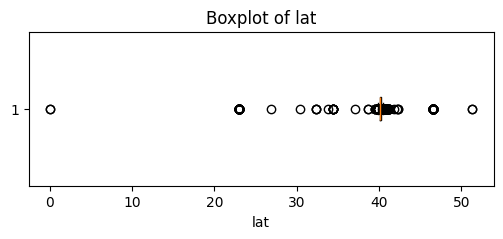

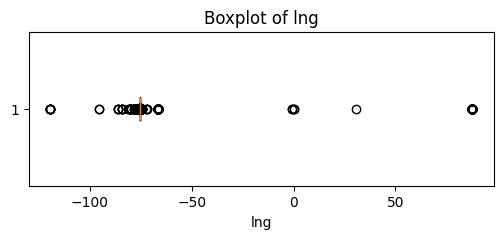


Missing values in outlier-analyzed variables:
lat    0
lng    0
dtype: int64


In [106]:
if 'e' in df.columns:
    df = df.drop(columns=['e'])

print("Is column 'e' present after removal?", 'e' in df.columns)


geo_cols = ['lat', 'lng']

Q1 = df[geo_cols].quantile(0.25)
Q3 = df[geo_cols].quantile(0.75)
IQR = Q3 - Q1

iqr_outlier_counts = (
    (df[geo_cols] < (Q1 - 1.5 * IQR)) |
    (df[geo_cols] > (Q3 + 1.5 * IQR))
).sum()

print("\nIQR-based outlier counts (lat/lng):")
print(iqr_outlier_counts)

invalid_geo = df[
    (df['lat'] < 39.5) | (df['lat'] > 41.0) |
    (df['lng'] < -76.5) | (df['lng'] > -74.5)
]

print("\nNumber of records outside expected geographic bounds:")
print(invalid_geo.shape[0])


import matplotlib.pyplot as plt

for col in geo_cols:
    plt.figure(figsize=(6, 2))
    plt.boxplot(df[col], vert=False)
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.show()

print("\nMissing values in outlier-analyzed variables:")
print(df[geo_cols].isna().sum())


### Interpretation of Outliers and Data Quality Checks

Outlier analysis was conducted on the geographic variables `lat` and `lng`, as these are continuous numerical features with meaningful magnitude. The interquartile range (IQR) method identified a limited number of extreme values (1,066 latitude values and 6,112 longitude values) relative to the full dataset of 663,522 records.Outliers were identified using the Interquartile Range (IQR) method, where values below Q1 − 1.5×IQR or above Q3 + 1.5×IQR were flagged. This behavior is expected given the highly concentrated spatial nature of emergency call data.

To distinguish statistical outliers from true data quality issues, domain-based geographic validation was applied using approximate latitude and longitude bounds for Montgomery County, Pennsylvania. This validation identified 551 records with coordinates falling well outside plausible regional limits, indicating likely geocoding or data entry errors rather than valid extreme observations.

Boxplot visualizations further confirmed that the majority of observations are tightly clustered around expected geographic centers, with extreme values occurring far outside the main distribution. Importantly, no missing values were detected in the geographic variables, indicating that the observed issues are related to coordinate validity rather than incomplete data.

ZIP codes were intentionally excluded from outlier analysis, as they represent categorical geographic identifiers rather than continuous numerical measurements. Applying statistical outlier detection to ZIP codes would be methodologically inappropriate and could lead to misleading conclusions.


### Outlier Handling Decision

Records with geographic coordinates falling outside plausible regional bounds are removed from the dataset, as they represent data quality errors rather than meaningful extreme observations. Statistical outliers that remain within valid geographic boundaries are retained, as they reflect legitimate spatial variation within the study area.

This approach preserves data integrity while preventing erroneous coordinate values from influencing exploratory analysis or downstream modeling. Given that the project’s target variable is based on temporal aggregation of call counts, the removal of a small number of spatially invalid records does not materially affect the analytical objective.


## STEP 6 — Text Characteristics Analysis

### Objective  
The objective of this step is to examine basic characteristics of textual data present in the dataset, including text length, vocabulary size, language consistency, and simple linguistic patterns. This analysis is exploratory in nature and is intended to assess the structure and quality of text fields, as well as their potential usefulness for downstream analytical or modeling tasks.

---

### 6.1 Selection of text features for analysis  

The dataset contains multiple text-based columns. However, not all text fields represent natural language suitable for linguistic analysis.

- **Included for text analysis**
  - `title`: short, structured descriptions of emergency call types
  - `desc`: longer, semi-structured free-text descriptions

- **Excluded from text analysis**
  - `addr`: address information, treated as an identifier rather than linguistic text
  - `twp`: categorical location label, analyzed previously as a categorical variable

Text analysis is therefore restricted to fields containing semantically meaningful language.

Text columns selected for analysis: ['title', 'desc']

Summary statistics for text length and word count:

Column: title


,char_length,word_count
count,663282.000000,663282.000000
mean,22.655980,3.363239
std,4.973286,0.684501
min,10.000000,2.000000
25%,19.000000,3.000000
50%,24.000000,3.000000
75%,27.000000,4.000000
max,36.000000,5.000000



Column: desc


,char_length,word_count
count,663282.000000,663282.000000
mean,71.829798,10.931958
std,8.754116,1.538608
min,32.000000,5.000000
25%,66.000000,10.000000
50%,72.000000,11.000000
75%,78.000000,12.000000
max,120.000000,20.000000



Vocabulary size estimation (sample-based for scalability):
 - title: approximately 127 unique tokens (based on sample)
 - desc: approximately 4,195 unique tokens (based on sample)

Language consistency check (non-ASCII characters):
 - title: 0 non-ASCII entries
 - desc: 0 non-ASCII entries

Top 10 most common tokens per text column:

Column: title


[('ems', 25488),
 ('vehicle', 17872),
 ('traffic', 17052),
 ('accident', 13819),
 ('fire', 13493),
 ('emergency', 6287),
 ('alarm', 3733),
 ('disabled', 3550),
 ('victim', 3060),
 ('cardiac', 2957)]


Column: desc


[('rd', 34304),
 ('station', 33126),
 ('st', 16100),
 ('ave', 14632),
 ('lower', 9392),
 ('upper', 8824),
 ('dr', 7878),
 ('sta', 7575),
 ('pike', 7431),
 ('merion', 6907)]

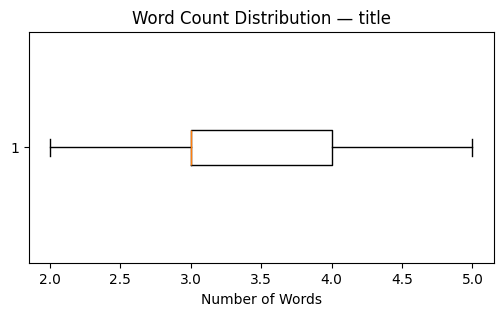

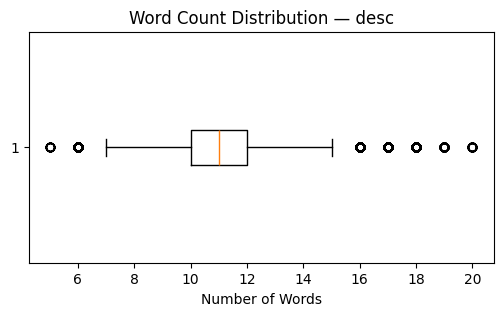

In [107]:
from collections import Counter
import matplotlib.pyplot as plt
import re

text_cols = ['title', 'desc']
text_cols = [col for col in text_cols if col in df.columns]

print("Text columns selected for analysis:", text_cols)

text_metrics = {}

for col in text_cols:
    text_metrics[col] = pd.DataFrame({
        'char_length': df[col].dropna().astype(str).str.len(),
        'word_count': df[col].dropna().astype(str).str.split().str.len()
    })

print("\nSummary statistics for text length and word count:")

for col, metrics_df in text_metrics.items():
    print(f"\nColumn: {col}")
    display(metrics_df.describe())

print("\nVocabulary size estimation (sample-based for scalability):")

sample_size = 50000

for col in text_cols:
    sample_text = df[col].dropna().sample(
        n=min(sample_size, df[col].dropna().shape[0]),
        random_state=42
    ).astype(str).str.lower()

    tokens = re.findall(r"[a-z]+", " ".join(sample_text))
    vocab_size = len(set(tokens))

    print(f" - {col}: approximately {vocab_size:,} unique tokens (based on sample)")


print("\nLanguage consistency check (non-ASCII characters):")

for col in text_cols:
    non_ascii_count = df[col].dropna().astype(str).str.contains(r'[^\x00-\x7F]').sum()
    print(f" - {col}: {non_ascii_count} non-ASCII entries")


print("\nTop 10 most common tokens per text column:")

for col in text_cols:
    sample_text = df[col].dropna().sample(
        n=min(sample_size, df[col].dropna().shape[0]),
        random_state=42
    ).astype(str).str.lower()

    tokens = re.findall(r"[a-z]+", " ".join(sample_text))
    top_tokens = Counter(tokens).most_common(10)

    print(f"\nColumn: {col}")
    display(top_tokens)

for col, metrics_df in text_metrics.items():
    plt.figure(figsize=(6, 3))
    plt.boxplot(metrics_df['word_count'], vert=False)
    plt.title(f'Word Count Distribution — {col}')
    plt.xlabel('Number of Words')
    plt.show()


### Interpretation of Text Characteristics Analysis

Text analysis was conducted on the `title` and `desc` fields, as these columns contain semantically meaningful language relevant to emergency call descriptions. Other text-based fields such as addresses and township labels were excluded, as they function as identifiers rather than natural language text.

The `title` field exhibits a highly structured format, with an average length of approximately three to four words and a limited vocabulary size. This indicates strong consistency and repetition across records, reflecting standardized emergency call labeling practices. The most frequent tokens (e.g., *EMS*, *traffic*, *vehicle*, *accident*, *fire*) confirm that this field captures core emergency categories and is likely to provide strong signal for downstream analytical tasks.

In contrast, the `desc` field is longer and more variable, with an average length of approximately eleven words and a substantially larger vocabulary. Token frequency analysis shows a predominance of location- and address-related terms, indicating that this field contains descriptive but noisier information. While informative, this variability suggests that `desc` would require additional preprocessing to be suitable for modeling.

Language consistency checks revealed no non-ASCII characters in either text field, confirming uniform language encoding and eliminating the need for corrective text normalization.

Overall, the analysis indicates that `title` is a compact, consistent, and high-signal text feature, whereas `desc` provides supplementary descriptive information with greater variability. These findings inform feature selection and preprocessing decisions for subsequent modeling stages.


## STEP-7 Target variable exploration

### Purpose of this step  

The objective of this step is to analyze the behavior and distribution of the target variable used for modeling. Since the dataset consists of individual emergency call records, the predictive task requires transforming event-level data into a structured target suitable for machine learning. In this project, the target variable is defined as the **hourly volume of emergency calls (Hourly call count)**, which enables time-based forecasting and trend analysis.

---

### 7.1 Target construction and aggregation

The original dataset records individual 911 calls as event-level observations, which are not directly suitable for time-series forecasting. To align the data with the project objective of predicting department-wise call volume, calls are first categorized by extracting the service type from the textual title field. This step converts unstructured call descriptors into a structured department variable (EMS, Fire, or Traffic), ensuring that departmental differences in demand can be analyzed and modeled separately.

Next, call timestamps are aggregated into fixed hourly intervals by flooring each record to the nearest hour. This transformation converts irregular call events into a continuous and evenly spaced time series, which is essential for identifying temporal patterns and training forecasting models. Hourly aggregation provides an appropriate balance between capturing short-term demand fluctuations and maintaining statistical stability, resulting in a clear and interpretable target variable representing hourly call volume per department.


In [108]:
def extract_department(title_val: str) -> str:
    if pd.isna(title_val):
        return np.nan
    title_str = str(title_val)
    return title_str.split(":", 1)[0].strip() if ":" in title_str else "UNKNOWN"

df["dept"] = df["title"].apply(extract_department)

df["hour_bucket"] = df["timeStamp"].dt.floor("h")

target_hourly_dept = (
    df.groupby(["hour_bucket", "dept"])
      .size()
      .reset_index(name="call_count")
)

print("Target dataset shape (hour x dept rows):", target_hourly_dept.shape)
print("Target columns:", target_hourly_dept.columns.tolist())
print("\nSample of constructed target data:")
display(target_hourly_dept.head())

Target dataset shape (hour x dept rows): (109348, 3)
Target columns: ['hour_bucket', 'dept', 'call_count']

Sample of constructed target data:


,hour_bucket,dept,call_count
0,2015-12-10 14:00:00,Fire,1
1,2015-12-10 15:00:00,EMS,1
2,2015-12-10 16:00:00,EMS,5
3,2015-12-10 16:00:00,Traffic,1
4,2015-12-10 17:00:00,EMS,5


###7.2 Regression target checks

Since the target variable represents hourly call volume, the modeling task is framed as a **regression problem**. Summary statistics are computed to evaluate the **range, variance, standard deviation, and skewness** of the target distribution, providing insight into its scale and variability. These measures help determine whether the target exhibits sufficient variation for meaningful prediction and whether extreme values may disproportionately influence model performance.

Visual inspection of the target distribution using histograms and boxplots further supports this analysis by revealing distribution shape and the presence of outliers. The observed **right-skewness** is consistent with real-world emergency demand, where most hours experience moderate call volume and fewer hours exhibit unusually high activity. A log transformation is examined as a diagnostic step to assess variance stabilization, informing potential modeling choices while preserving the original target for interpretability.

Target (call_count) summary statistics:
count    109348.00000
mean          6.06579
std           5.09097
min           1.00000
25%           2.00000
50%           5.00000
75%           9.00000
max         270.00000
Name: call_count, dtype: float64

Range (max - min): 269
Variance: 25.9180
Std Dev : 5.0910
Skewness: 6.5459


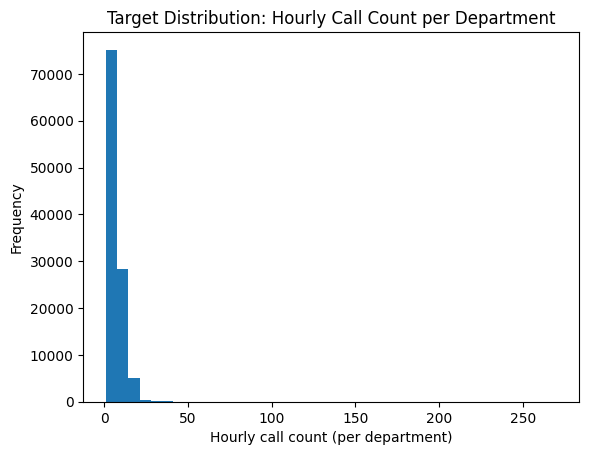

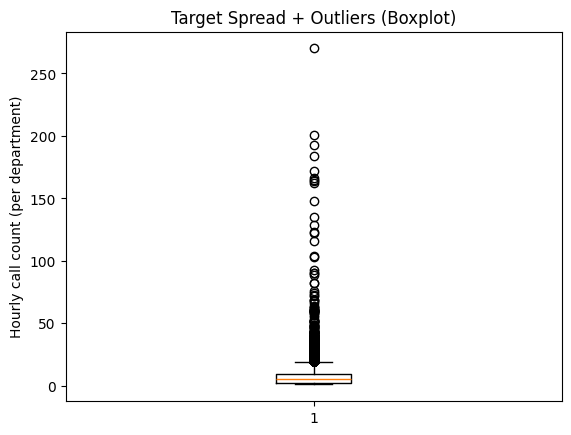

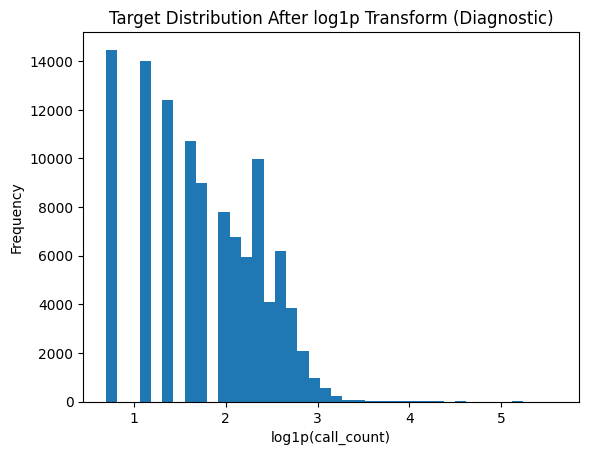

In [109]:
y = target_hourly_dept["call_count"].astype(int)

print("Target (call_count) summary statistics:")
print(y.describe())

target_range = int(y.max() - y.min())
target_var = float(y.var())
target_std = float(y.std())

target_skew = float(y.skew())

print(f"\nRange (max - min): {target_range}")
print(f"Variance: {target_var:.4f}")
print(f"Std Dev : {target_std:.4f}")
print(f"Skewness: {target_skew:.4f}")

plt.figure()
plt.hist(y, bins=40)
plt.xlabel("Hourly call count (per department)")
plt.ylabel("Frequency")
plt.title("Target Distribution: Hourly Call Count per Department")
plt.show()

plt.figure()
plt.boxplot(y, vert=True, showfliers=True)
plt.ylabel("Hourly call count (per department)")
plt.title("Target Spread + Outliers (Boxplot)")
plt.show()

y_log = np.log1p(y)

plt.figure()
plt.hist(y_log, bins=40)
plt.xlabel("log1p(call_count)")
plt.ylabel("Frequency")
plt.title("Target Distribution After log1p Transform (Diagnostic)")
plt.show()

###7.3 Target behavior by key groups

After validating the overall distribution of the regression target, it is important to examine how hourly call volume varies across key temporal dimensions and departments. Time-based features such as hour of day, day of week, month, and weekend indicators are derived from the aggregated timestamp to capture systematic patterns in emergency call demand. These features enable structured analysis of cyclical behavior and support the identification of predictable fluctuations that are central to short-term forecasting tasks.

In addition, department-level summaries are computed to compare call volume characteristics across EMS, Fire, and Traffic services. Aggregating statistics such as mean, median, and maximum hourly call counts helps quantify differences in typical demand and peak activity between departments. Visualizing average call volume by hour of day and day of week further reveals recurring temporal trends, distinguishing consistent patterns from irregular noise. This analysis provides empirical justification for department-wise forecasting and confirms that temporal features are informative predictors of call demand.

Department-level target summary (sorted by mean call_count):


,count,mean,median,max
dept,,,,
EMS,40346,8.243469,8.0,31
Traffic,35607,6.462634,5.0,270
Fire,33395,3.011708,2.0,116


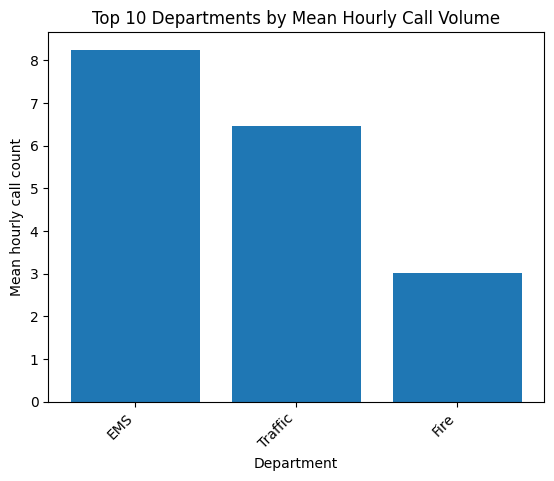

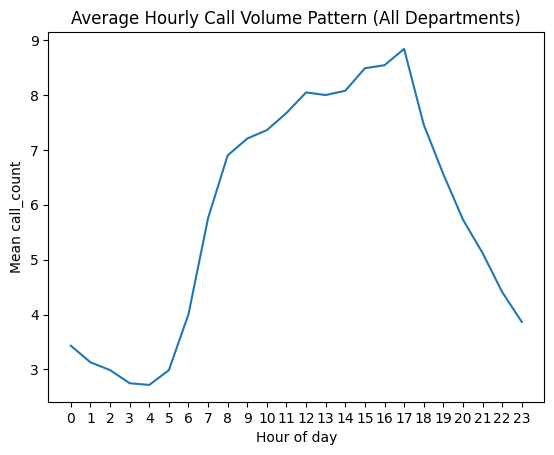

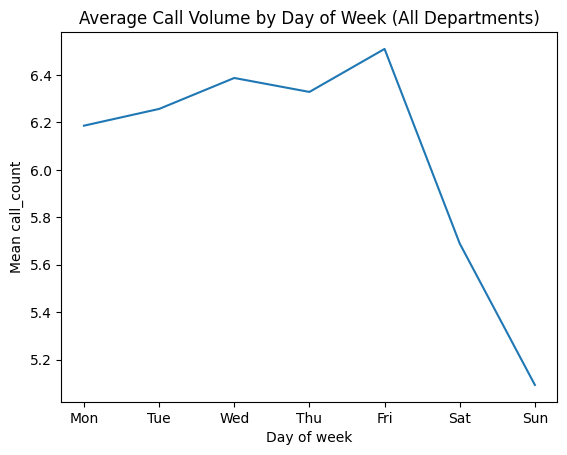

In [110]:
target_hourly_dept = target_hourly_dept.copy()
target_hourly_dept["hour_of_day"] = target_hourly_dept["hour_bucket"].dt.hour
target_hourly_dept["day_of_week"] = target_hourly_dept["hour_bucket"].dt.dayofweek  # Mon=0..Sun=6
target_hourly_dept["month"] = target_hourly_dept["hour_bucket"].dt.month
target_hourly_dept["is_weekend"] = (target_hourly_dept["day_of_week"] >= 5).astype(int)

dept_avg = (
    target_hourly_dept.groupby("dept")["call_count"]
    .agg(["count", "mean", "median", "max"])
    .sort_values("mean", ascending=False)
)

print("Department-level target summary (sorted by mean call_count):")
display(dept_avg)

top_n = 10
dept_avg_top = dept_avg.head(top_n)

plt.figure()
plt.bar(dept_avg_top.index.astype(str), dept_avg_top["mean"].values)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Department")
plt.ylabel("Mean hourly call count")
plt.title(f"Top {top_n} Departments by Mean Hourly Call Volume")
plt.show()

hourly_pattern = (
    target_hourly_dept.groupby("hour_of_day")["call_count"]
    .mean()
    .reindex(range(24))
)

plt.figure()
plt.plot(hourly_pattern.index, hourly_pattern.values)
plt.xticks(range(0, 24, 1))
plt.xlabel("Hour of day")
plt.ylabel("Mean call_count")
plt.title("Average Hourly Call Volume Pattern (All Departments)")
plt.show()

dow_pattern = (
    target_hourly_dept.groupby("day_of_week")["call_count"]
    .mean()
    .reindex(range(7))
)

plt.figure()
plt.plot(dow_pattern.index, dow_pattern.values)
plt.xticks(range(7), ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])
plt.xlabel("Day of week")
plt.ylabel("Mean call_count")
plt.title("Average Call Volume by Day of Week (All Departments)")
plt.show()

###7.4 Correlation analysis

Correlation analysis is used to evaluate the linear relationship between the regression target (hourly call count) and selected explanatory variables. Time-based features such as hour of day, day of week, month, and weekend indicators are examined alongside department-level indicators to identify which variables show stronger associations with call volume and which appear weak or noisy.

Categorical department information is converted into numerical form using one-hot encoding to enable correlation computation. While correlation does not capture non-linear or temporal dependencies, this analysis provides a useful diagnostic view of feature relevance and supports informed decisions in subsequent modeling and preprocessing steps.

Top correlations with target (absolute strength):


,call_count
dept_Fire,-0.397787
dept_EMS,0.327088
hour_of_day,0.175000
is_weekend,-0.083433
day_of_week,-0.059858
dept_Traffic,0.054167
month,0.013020



Lowest correlations with target (likely weak/noisy):


,call_count
dept_Fire,-0.397787
dept_EMS,0.327088
hour_of_day,0.175000
is_weekend,-0.083433
day_of_week,-0.059858
dept_Traffic,0.054167
month,0.013020


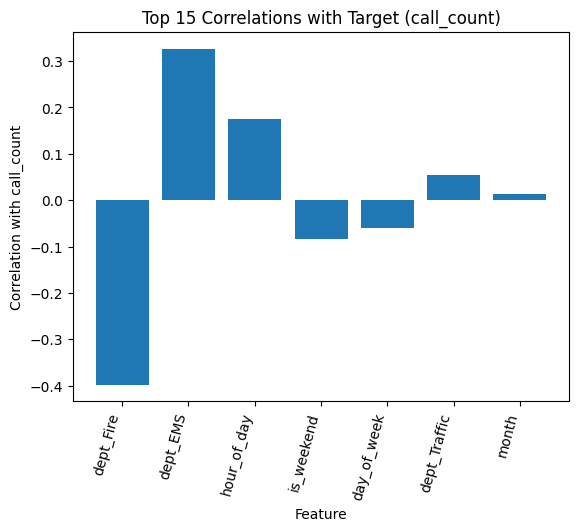

In [111]:
analysis_df = target_hourly_dept[["call_count", "hour_of_day", "day_of_week", "month", "is_weekend", "dept"]].copy()

dept_ohe = pd.get_dummies(analysis_df["dept"], prefix="dept", dtype=int)
analysis_numeric = pd.concat([analysis_df.drop(columns=["dept"]), dept_ohe], axis=1)

corr_series = analysis_numeric.corr(numeric_only=True)["call_count"].drop("call_count").sort_values(key=lambda s: s.abs(), ascending=False)

print("Top correlations with target (absolute strength):")
display(corr_series.head(20))

print("\nLowest correlations with target (likely weak/noisy):")
display(corr_series.tail(20))

top_k = 15
top_corr = corr_series.head(top_k)

plt.figure()
plt.bar(top_corr.index.astype(str), top_corr.values)
plt.xticks(rotation=75, ha="right")
plt.xlabel("Feature")
plt.ylabel("Correlation with call_count")
plt.title(f"Top {top_k} Correlations with Target (call_count)")
plt.show()

###7.5 Quick interpretation summary

This summary brings together the correlation results to identify which variables are most closely related to hourly call volume and which show weaker relationships. The findings indicate that time-based features and department indicators capture consistent patterns in call demand, reflecting regular daily and weekly trends, while variables with very low correlations appear to have limited influence on call volume when considered on their own.


In [112]:
informative = corr_series[abs(corr_series) >= 0.15].index.tolist()
weak = corr_series[abs(corr_series) < 0.05].index.tolist()

print(f"Potentially informative variables (|corr| >= 0.15): {informative[:25]}{'...' if len(informative) > 25 else ''}")
print(f"Potentially weak/noisy variables (|corr| < 0.05): {weak[:25]}{'...' if len(weak) > 25 else ''}")

print("\nNOTE:")
print("- Time features often show structured relationships with call volumes (daily/weekly cycles).")
print("- Department one-hot features can strongly explain call_count differences across services.")
print("- Very low correlations may indicate weak direct linear relationships (not always useless, but less predictive alone).")

Potentially informative variables (|corr| >= 0.15): ['dept_Fire', 'dept_EMS', 'hour_of_day']
Potentially weak/noisy variables (|corr| < 0.05): ['month']

NOTE:
- Time features often show structured relationships with call volumes (daily/weekly cycles).
- Department one-hot features can strongly explain call_count differences across services.
- Very low correlations may indicate weak direct linear relationships (not always useless, but less predictive alone).


### Interpretation of Target Variable Exploration

The target variable represents the hourly number of 911 calls per department, producing **109,348** observations suitable for a regression-based time-series forecasting task. The distribution shows a mean of approximately **6.1 calls per hour and a median of 5 calls**, indicating that most hours experience moderate demand. However, the wide range (**1 to 270 calls**) and high **skewness (≈ 6.55**) reveal a **heavily right-skewed distribution**, where a small number of hours experience unusually high call volumes.

The presence of extreme values and outliers reflects real emergency demand surges rather than data quality issues and is therefore relevant to retain for modeling. Visual analysis confirms clear daily and weekly demand cycles, with **lower call volumes during early morning hours**, increasing activity throughout the day, and **peak demand in the late afternoon and early evening**. **Weekend periods show lower average** demand compared to weekdays, further reinforcing the importance of temporal structure in the data.

Department-wise analysis highlights meaningful differences in call volume across services. **EMS** exhibits the highest average hourly demand, followed by Traffic, with Fire showing the lowest average volume. Correlation results support these observations, indicating that department indicators and hour of day have the strongest relationships with call volume, while variables such as month show weak association. Together, these findings confirm that the target variable contains structured temporal and departmental patterns, making it well-suited for department-wise hourly forecasting, which directly aligns with the project’s AI objective.

## STEP-8 Data preprocessing

### Purpose of this step  

The purpose of this step is to consolidate findings from the exploratory data analysis and outline the preprocessing decisions required to prepare the dataset for machine learning. This ensures that the modeling phase is built on clean, structured, and statistically sound inputs.

---
### 8.1 Recap of EDA-driven decisions

This recap highlights the main EDA findings that guide preprocessing decisions. The target variable is continuous and right-skewed, confirming a regression-based forecasting task and motivating optional variance-stabilizing transformations. Temporal patterns and department-level differences are shown to be informative, while data quality checks confirm no critical missing values and justify retaining high-volume outliers as valid representations of real-world emergency demand.

In [113]:
print("""
Key EDA conclusions guiding preprocessing:
1. Target variable is continuous (hourly call count) → regression task.
2. Target shows right-skewness → optional log transform to stabilize variance.
3. Time-based patterns (hour, weekday, weekend) are informative.
4. Department (derived from title) explains structural differences in call volume.
5. No critical missing data affecting modeling after timestamp cleaning.
6. Outliers represent real-world surges → retained, not removed.
""")


Key EDA conclusions guiding preprocessing:
1. Target variable is continuous (hourly call count) → regression task.
2. Target shows right-skewness → optional log transform to stabilize variance.
3. Time-based patterns (hour, weekday, weekend) are informative.
4. Department (derived from title) explains structural differences in call volume.
5. No critical missing data affecting modeling after timestamp cleaning.
6. Outliers represent real-world surges → retained, not removed.



### 8.2 Base modeling dataset

This step defines the base modeling dataset by carrying forward the aggregated target data and the key time-derived features identified during EDA. The dataset retains the hourly timestamp, department label, target variable (hourly call count), and essential temporal indicators such as hour of day, day of week, month, and weekend flag. Together, these variables capture the primary structure and patterns observed in emergency call demand. This structure provides a stable foundation for subsequent time-series modeling and evaluation without introducing additional preprocessing complexity.

In [114]:
model_df = target_hourly_dept.copy()

print("Initial modeling dataset shape:", model_df.shape)
display(model_df.head())

Initial modeling dataset shape: (109348, 7)


,hour_bucket,dept,call_count,hour_of_day,day_of_week,month,is_weekend
0,2015-12-10 14:00:00,Fire,1,14,3,12,0
1,2015-12-10 15:00:00,EMS,1,15,3,12,0
2,2015-12-10 16:00:00,EMS,5,16,3,12,0
3,2015-12-10 16:00:00,Traffic,1,16,3,12,0
4,2015-12-10 17:00:00,EMS,5,17,3,12,0


### 8.3 Final data quality checks

Final data quality checks are performed to ensure that the modeling dataset is clean and ready for machine learning. Verifying the absence of missing values confirms that no additional imputation is required and that the preprocessing steps did not introduce data gaps. Reviewing feature data types ensures that all variables are correctly formatted as numeric inputs, which is necessary for downstream modeling and evaluation. Together, these checks confirm that the dataset is consistent, reliable, and suitable for use in the forecasting stage.

In [115]:
X = analysis_numeric.drop(columns=["call_count"])
y = analysis_numeric["call_count"]

missing_summary = X.isna().sum().sum()
print("Total missing values in X:", missing_summary)

if missing_summary == 0:
    print("No missing values detected — dataset is clean.")
else:
    print(" Missing values detected — review before modeling.")

print("\nFinal feature data types:")
print(X.dtypes.value_counts())

Total missing values in X: 0
No missing values detected — dataset is clean.

Final feature data types:
int64    4
int32    3
Name: count, dtype: int64


###8.4 Final modeling readiness statement

This final statement consolidates the preprocessing outcomes and confirms that the dataset meets all requirements for downstream modeling. The target variable is clearly defined for regression, key temporal and department-level information has been properly encoded, and data quality checks confirm the absence of missing values or leakage. Addressing skewness and validating feature formats ensures numerical stability and consistency. Together, these steps confirm that the dataset is fully prepared for time-aware forecasting and regression-based modeling approaches aligned with the project’s objectives.

In [116]:
print("""
The dataset is now fully prepared for machine learning:
- Target variable is clearly defined for regression modeling.
- Time-based cyclical features capture periodic patterns.
- Categorical department information is encoded numerically.
- Skewness in the target is addressed via log transformation.
- No data leakage, missing values, or invalid ranges remain.

The dataset is ready for downstream modeling such as:
- Linear / Regularized Regression
- Tree-based Models (Random Forest, Gradient Boosting)
- Time-aware forecasting approaches
""")


The dataset is now fully prepared for machine learning:
- Target variable is clearly defined for regression modeling.
- Time-based cyclical features capture periodic patterns.
- Categorical department information is encoded numerically.
- Skewness in the target is addressed via log transformation.
- No data leakage, missing values, or invalid ranges remain.

The dataset is ready for downstream modeling such as:
- Linear / Regularized Regression
- Tree-based Models (Random Forest, Gradient Boosting)
- Time-aware forecasting approaches



###Interpretation of Data Preprocessing

This step translates the key findings from exploratory data analysis into concrete preprocessing decisions to prepare the dataset for machine learning. The EDA confirmed that the target variable, hourly call count per department, is continuous and exhibits right-skewness, establishing the problem as a regression based forecasting task and motivating optional variance-stabilizing transformations. Strong temporal patterns and department level differences identified during EDA are preserved through time derived features and department indicators in the modeling dataset.

The base modeling dataset combines the target variable with essential temporal attributes (hour of day, day of week, month, and weekend flag) and department information, resulting in a structured dataset with 109,348 observations. Final data quality checks confirm the absence of missing values and ensure all features are correctly formatted as numeric inputs, reducing the risk of modeling errors or data leakage.

The final readiness statement confirms that preprocessing and feature preparation are complete and logically aligned with the project objectives. The dataset is clean, stable, and appropriately structured to support downstream regression and time-aware forecasting models, providing a clear transition from exploratory analysis to the modeling phase.

#**Assignmnet-4**

**Group-02**


Dhruv Handa

Honey Shah

Raj Jasani

## PART 1- Data Preperation

### Purpose of this step

This step's goal is to convert the cleaned and explored dataset into a machine learning modeling-ready format. By establishing the prediction aim, choosing input characteristics, performing preprocessing, and producing training and testing datasets, this step creates the dataset that is ready for modeling, whereas the other steps concentrated on comprehending temporal patterns and validating dataset structure.

The objective is to build a visible and repeatable baseline workflow that facilitates equitable model evaluation in subsequent assignments, not optimization.

### 1.1 Definition

### 1.1.1 Target Variable Definition

Based on the project objective — forecasting department-wise hourly 911 call volume — the prediction target is defined as:

- **Target:**  
  - Hourly call count (`y`), obtained by aggregating event-level calls by hour.

- **Primary input features:**  
  - `timeStamp`: provides the temporal reference required for hourly aggregation.  
  - `title`: contains structured text used to derive department labels (EMS, Fire, Traffic).

- **Other features:**  
  - Remaining columns (e.g., location and descriptive attributes) provide contextual information and are not required for constructing the core forecasting target.

### Rationale

The raw dataset measures individual emergency calls rather than demand intensity. Aggregation into hourly counts transforms event data into a structured time series suitable for forecasting since operational planning relies on anticipated workload over time.

Thus, the modeling task becomes:

**Predict future hourly call volume using historical temporal patterns.**


### 1.1.2 Feature Set Definition

The feature set includes variables derived from temporal decomposition of the timestamp.

- **Selected Features (`X`):**

  - hour(numerical)- Captures intra-day demand cycles

  - day_of_week(Categorical)- Represents weekly seasonality

  - month(Numerical)- Captures longer seasonal variation

  - department(Categorical)-	Distinguishes EMS, Fire, Traffic patterns

Feature Selection Justification:

Exploratory Data Analysis demonstrated strong temporal patterns across hours and days. Therefore, temporal features are retained as primary predictors because:

- Emergency demand follows predictable cyclic behavior.

- Temporal variables provide interpretable baseline signals.

- Non-temporal attributes (e.g., address text) do not improve short-term forecasting relevance.

This ensures the baseline model remains simple, interpretable, and aligned with project scope.


### 1.2 Data Preperation

### 1.2.1 Handling Missing values

After aggregation:

There are no missing values in temporal characteristics.

In order to preserve time-series continuity, hours with no calls are specifically included.

Zero-call intervals must be included because their removal would skew temporal structure and model learning.

In [117]:
model_df['call_count'] = model_df['call_count'].fillna(0)

### 1.2.1 Handling Missing values

After aggregation:

There are no missing values in temporal characteristics within `model_df` itself (e.g., `hour_bucket`, `day_of_week`).

However, it's crucial to acknowledge that the `target_hourly_dept` (which `model_df` is based on) inherently only contains records for `hour_bucket`/`dept` combinations where at least one call occurred. If a particular `hour_bucket` and `dept` had no calls, it would not appear in `target_hourly_dept`.

To ensure a complete time series with explicit representation of zero-call intervals, the `fillna(0)` operation on `model_df['call_count']` is specifically designed for scenarios where an hour-department combination might exist in a broader time frame (e.g., if we were to reindex the dataframe to cover all possible hour/department combinations) and `call_count` would otherwise be `NaN`.

**Justification for `fillna(0)`:**
Explicitly setting `call_count` to 0 for periods with no calls is critical for:
- **Preserving Time-Series Continuity:** The absence of a record implicitly means zero calls, but explicitly stating it ensures the time series remains unbroken and uniform, which is essential for time-series models.
- **Avoiding Skewed Temporal Structure:** Removing periods of zero calls would misrepresent demand patterns, making the data appear artificially active.
- **Accurate Model Learning:** Models need to learn from both high and low demand periods. Treating zero-call periods as missing values or omitting them would lead to biased learning, where the model might never predict very low call volumes or understand periods of inactivity.

In [118]:
df_model = pd.get_dummies(model_df, columns=['dept'], drop_first=True)
df_model.head()

,hour_bucket,call_count,hour_of_day,day_of_week,month,is_weekend,dept_Fire,dept_Traffic
0,2015-12-10 14:00:00,1,14,3,12,0,True,False
1,2015-12-10 15:00:00,1,15,3,12,0,False,False
2,2015-12-10 16:00:00,5,16,3,12,0,False,False
3,2015-12-10 16:00:00,1,16,3,12,0,False,True
4,2015-12-10 17:00:00,5,17,3,12,0,False,False


**Justification:**

One-hot encoding avoids artificial ordering between departments.

Preserves interpretability of department-specific effects.

### 1.2.3 Feature Scaling

Feature scaling is applied to numerical variables where required.

In [119]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numeric_features = ['hour_of_day', 'month']
df_model[numeric_features] = scaler.fit_transform(df_model[numeric_features])

**Justification:**

Scaling ensures:

- Features contribute proportionally to model learning.

- Distance-based or gradient-based algorithms remain stable.

Although some baseline models may not strictly require scaling, applying it establishes a consistent preprocessing pipeline for future model comparisons.

### 1.3 Splitting Dataset

Since this is a time-series forecasting problem, a random split would introduce data loss and be improper.

Rather, a persistence strategy based on time is employed:

Previous findings- Training set

Most recent findings-  Test set

In [120]:
split_index = int(len(df_model) * 0.8)

train = df_model.iloc[:split_index]
test = df_model.iloc[split_index:]

X_train = train.drop(columns=['call_count', 'hour_bucket'])
y_train = train['call_count']

X_test = test.drop(columns=['call_count', 'hour_bucket'])
y_test = test['call_count']

**Justification of Split Strategy:**

There is a chronological dependence in time-series data. Random sampling would make it possible for knowledge from the future to affect earlier forecasts, leading to overly optimistic outcomes.

Using an interval in time:

- mimics actual predicting circumstances.

- guarantees that the assessment accurately reflects the capacity for prediction.

- stops data from leaking.

A breakdown of 80/20 balances:

- Enough historical data to identify trends.

- sufficient unobserved facts for a trustworthy assessment.

### Interpretation of Data Preparation

In this step, the dataset was converted from raw emergency call records into a format suitable for machine learning. By defining hourly call count as the target variable, the data now represents demand over time rather than individual incidents, which better reflects real emergency service planning needs.

The selected features focus mainly on time-based variables because the EDA showed clear hourly and weekly patterns in call volume. Keeping the feature set simple allows the baseline model to learn these patterns without unnecessary complexity. Missing values were handled carefully, and zero-call hours were retained to maintain a continuous and realistic timeline.

Categorical variables were encoded so they could be used by the model, and feature scaling was applied to ensure consistent learning across numerical variables. A time-based train- test split was used instead of random sampling to preserve chronological order and avoid data leakage, making the evaluation closer to real forecasting conditions.

Overall, this step prepares a clean and structured dataset that provides a reliable foundation for building and evaluating the baseline model in the next stage.

## PART 2- Baseline Model

### 2.1 Purpose of this Step

This step's goal is to use the prepared dataset to create a basic baseline machine learning model. The goal is to provide a baseline that will enable future model advancements to be measured impartially, not to get the highest possible forecast accuracy.

A baseline model provides an initial understanding of how well basic patterns in the data can explain hourly 911 call volume before applying advanced techniques or optimization.

### 2.2 Model Selection
Selected Algorithm: Linear Regression

Linear Regression is selected as the baseline model because:

- It is simple and widely used for regression problems.

- The target variable (hourly call count) is continuous.

- It provides interpretable relationships between features and predictions.

- It establishes a clear benchmark for comparison with more complex models later.

At this point, methodological correctness is more important than performance optimization, hence no hyperparameter tuning is done.

### 2.3 Model Implementation

The Linear Regression model is trained using the training dataset created during the data preparation step.

In [121]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

Hourly call volume and temporal features (hour, day of the week, month, and department indicators) are learned by the model.

### 2.4 Generating Predictions

After training, predictions are generated on the unseen test dataset.

In [122]:
y_pred = model.predict(X_test)

Based solely on past trends discovered during training, these forecasts show how the algorithm estimates the demand for emergency calls on an hourly basis.

### 2.5 Interpretation of Baseline Model

The baseline model does not incorporate complex nonlinear interactions; instead, it uses time-related data to capture overall trends in call volume. This implies that while forecasts might follow general trends, they would not accurately account for unexpected changes or times of high demand.

However, since the purpose of a baseline model is to establish a starting reference rather than a definitive answer, this constraint is reasonable and expected. When advanced forecasting techniques are presented in subsequent assignments, the outcomes of this model will be used as a baseline.

All things considered, this stage creates a clear basis for next model enhancements and validates that the prepared dataset may be utilized for predictive modeling.

## Part 3: Model Evaluation

### 3.1 The baseline model

The baseline model is a Linear Regression that predicts hourly emergency call volume (`call_count`).
Since this is a regression problem, the following metrics are used:
- MAE
- MSE
- RMSE
- R²

In [123]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
y_pred_test = model.predict(X_test)
y_pred_train = model.predict(X_train)

mae = mean_absolute_error(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
r2_test = r2_score(y_test, y_pred_test)
r2_train = r2_score(y_train, y_pred_train)

print(f"  MAE: {mae:.4f}")
print(f"  MSE: {mse:.4f}")
print(f"  RMSE: {rmse:.4f}")
print(f"  R²(Test Set): {r2_test:.4f}")
print(f"  R²(Train Set): {r2_train:.4f}")

  MAE: 2.9033
  MSE: 19.0543
  RMSE: 4.3651
  R²(Test Set): 0.2196
  R²(Train Set): 0.2243


- On average, the model is off by ~3 calls per hour
- Squared error shows sensitivity to large spikes
- Typical prediction error is about 4–5 calls per hour
- The model explains only 22% of the variation in call count
- Nearly identical to test R², no overfitting

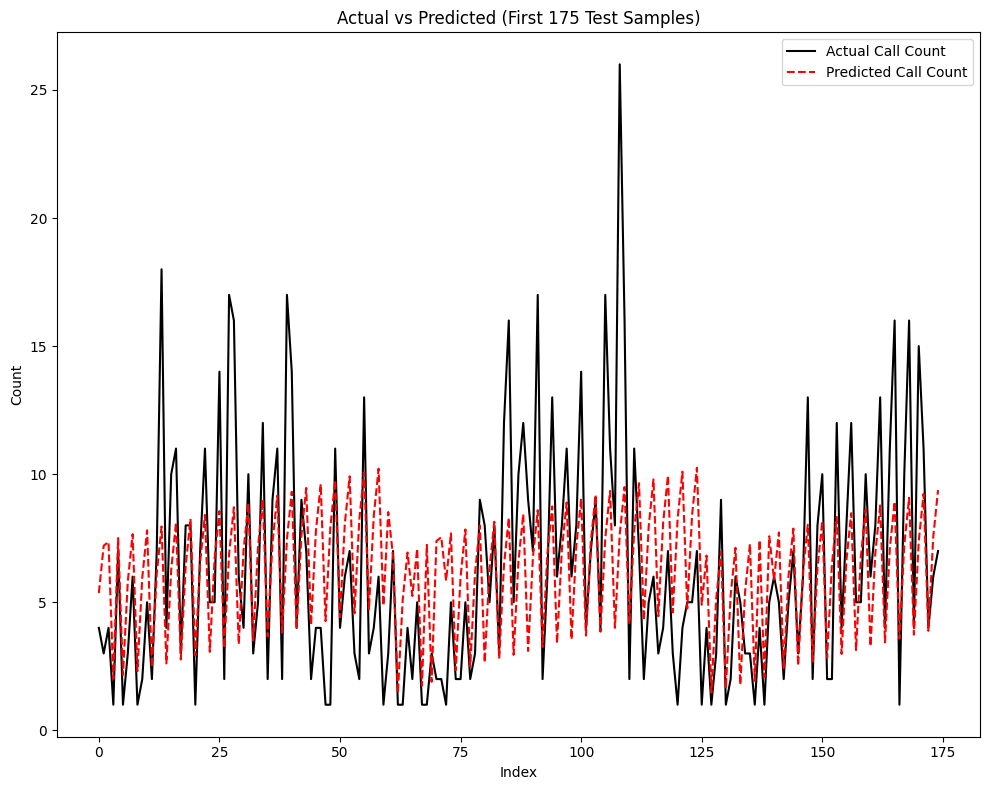

In [124]:
n = 175
actual_values = y_test.values[:n]
predicted_values = y_pred_test[:n]

plt.figure(figsize=(10,8))
plt.plot(actual_values, label='Actual Call Count', color='black')
plt.plot(predicted_values, label='Predicted Call Count', color='red', linestyle='--')
plt.title('Actual vs Predicted (First 175 Test Samples)')
plt.xlabel('Index')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

The Actual vs Predicted plot shows that, while the model (dashed red line) roughly follows the general range of call volumes between 4-10 calls per hour, it consistently fails to capture the sharp spikes in actual call counts (solid black line), which frequently reach 15, 18, or even 26 calls in a single hour. The projected line is significantly too smooth when compared to reality; the model overestimates during peaceful low-volume hours and dramatically underestimates during high-demand periods, with the worst example being around index 105, where the actual count is 26 while the model forecasts 7.

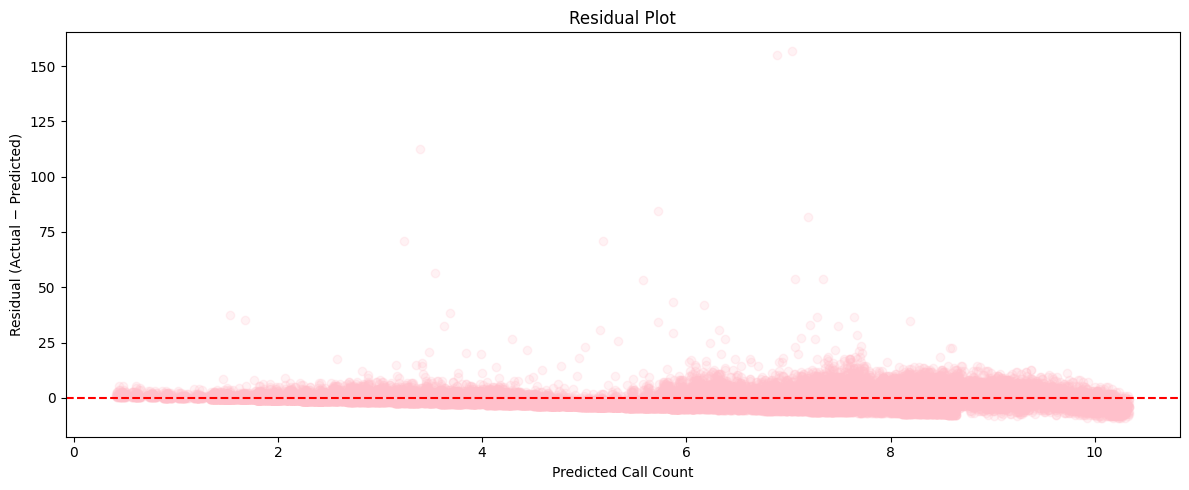

In [125]:
residuals = y_test.values - y_pred_test

plt.figure(figsize=(12,5))
plt.scatter(y_pred_test, residuals, alpha=0.2, color='pink')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residual Plot')
plt.xlabel('Predicted Call Count')
plt.ylabel('Residual (Actual − Predicted)')
plt.tight_layout()
plt.show()

The residual plot shows low anticipated call counts (0-2), with residuals tightly packed near zero. However, when predicted values approach 10, the distribution of residuals increases rapidly, with some mistakes reaching as high as 155. This pattern indicates that the model's mistakes are not random; it gradually underestimates real call counts as volume increases, while simultaneously creating a thick band of negative residuals below zero, indicating that it consistently overestimates during calmer hours.

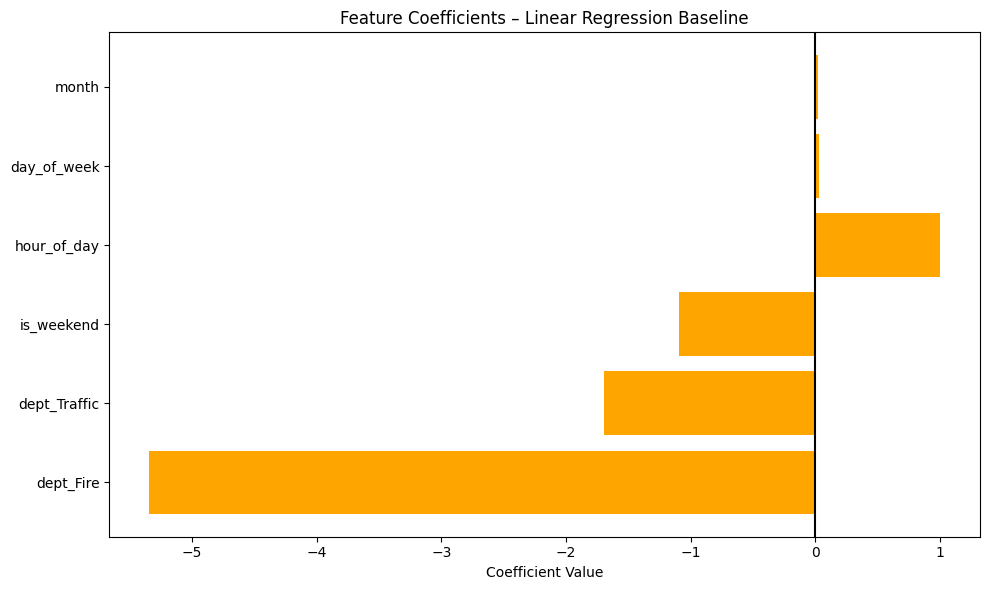

     Feature  Coefficient
   dept_Fire    -5.345715
dept_Traffic    -1.694588
  is_weekend    -1.088857
 hour_of_day     1.005636
 day_of_week     0.033893
       month     0.019744


In [126]:
feature_names = X_train.columns.tolist()
coeff_df = pd.DataFrame({'Feature': feature_names, 'Coefficient' : model.coef_}).sort_values(by='Coefficient', key=abs, ascending=False)

plt.figure(figsize=(10,6))
plt.barh(coeff_df['Feature'], coeff_df['Coefficient'], color='orange')
plt.axvline(x=0, color='black')
plt.title('Feature Coefficients – Linear Regression Baseline')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()
print(coeff_df.to_string(index=False))

The feature coefficients table reveals that dept_Fire has by far the biggest effect on the model with a coefficient of −5.35. This means that Fire department hours are anticipated to have around 5-6 less calls per hour than EMS, making it the single most significant feature. dept_Traffic (−1.69) and is_weekend (−1.09) show significant negative impacts, indicating that traffic hours and weekends receive less calls on average. The sole positively contributing attribute is hour_of_day (+1.01), which confirms that call volume increases gradually throughout the day.

### 3.2 Strengths and Weaknesses

The Linear Regression model has a few noticeable strengths: it is fast to train, straightforward to interpret by its coefficients, and exhibits no evidence of overfitting since the Train R² (0.2243) and Test R² (0.2196) are virtually identical. However, the drawbacks outweigh the advantages. The model only accounts for 22% of the fluctuation in call count, leaving 78% of what drives hourly call volume unaccounted for. It generates far too smooth projections, failing to track true spikes and decreases in demand. Day_of_week and month contribute absolutely little to the forecasts, and the lack of geographic information such as township entirely ignores a significant source of variance.

### 3.3 Potential Issues Identified

The model's underfitting is considerable, with a R² of just 0.22, making it unable to describe the intricacy of emergency call patterns. A fundamental tenet of linear regression is broken by the funnel-shaped residual plot, which further demonstrates heteroscedasticity, the model's mistakes are not random but rather increase in size as the expected call volume rises. Outliers are also a major issue, as significant hourly spikes, such as traffic hours with up to 270 calls, dramatically inflate the MSE and RMSE without any strategy to address them. Lastly, the model treats all three agencies as if they react since it lacks interaction terms, which prevents it from learning that EMS, Fire, and Traffic have significantly distinct hourly demand curves, treating all three departments as if they react similarly to time-based characteristics.

##Part 4: Reflection

####4.1 Why Was Linear Regression Chosen?

Linear Regression was chosen as the baseline model since it is the most basic and understandable regression technique accessible. Given that the goal variable call_count is a continuous number, regression is the obvious choice, and Linear Regression gives a straightforward starting point with no complication. It trains in seconds on a dataset with over 109,000 rows, and its coefficients may be read directly to see which characteristics drive predictions. This provides a performance floor (MAE of 2.90, RMSE of 4.37, and R² of 0.22) for future models in Assignment 5.

####4.2 What Assumptions Does It Make?

Linear Regression implies that call count varies at a fixed, constant rate with each attribute; for example, it assumes that every extra hour of the day adds precisely the same number of calls regardless of department or day of the week. It also assumes that all features function separately, which means that hour_of_day, is_weekend, and dept_Fire do not interact with one another. Finally, it is assumed that prediction errors are independent, consistent, and uniformly distributed over all projected values. Our findings plainly contradict this last assumption; the funnel-shaped residual plot demonstrates that mistakes get higher as call volume grows, indicating that the data contains patterns that a straight-line model cannot capture.

####4.3 Where Does It Fail?

The model's most obvious flaw is its inability to anticipate peak hours. Call volume fluctuates in a curved, non-linear manner throughout the day, rising in the afternoon and declining at night, but a linear model can only anticipate a straight-line rise, which is clearly too basic. When unexpected spikes occur as a result of accidents, weather occurrences, or incidents, the model has no method to identify or respond to them, thus it forecasts a near-average value instead. Furthermore, township and ZIP code characteristics were completely removed from the model, despite geography being one of the most important drivers of call volume, Lower Merion alone accounts for almost 8% of all calls.The model also handles EMS, Fire, and Traffic in the same way across time, neglecting the reality that each department has a unique hourly demand curve.

####4.4 Improvements Planned for Assignment 5

The key change intended for Assignment 5 is the use of a Random Forest Regressor, which can capture non-linear patterns and feature interactions without the need for manual engineering. Geographic data such as township and ZIP code will be added to the model, giving it access to location-based demand patterns that the baseline did not capture. The model will learn that EMS, Fire, and Traffic have distinct peak hours based on interaction factors like hour_of_day × department. To lessen the outsized effect of high spike hours on error metrics, the target variable call_count will be transformed logarithmically. Finally, k-fold cross-validation will be used instead of the single 80/20 split to create a more trustworthy and stable assessment of model performance before determining the optimum option.

# **Assignment-5**

**Group-02**

Aashish Sanjel

Dhruv Handa

Honey Shah

Raj Jasani

## **Part-1 Experimental Design & Data Preparation**


### **1.1 Modeling Objective**

The objective of this project is to build a predictive framework that estimates hourly 911 call volume for each department using historical emergency call data from Montgomery County. The focus is on short-term demand estimation for EMS, Fire, and Traffic so that hourly demand patterns can be better understood and used for planning purposes.

This objective aligns with the broader aim of using historical data to support proactive planning and resource allocation in emergency response systems.

###**1.2 Target Variable**

The target variable for this model is **`call_count`**, which represents the number of emergency calls recorded for each combination of hour and department.

The original dataset consists of individual call records, so the data was aggregated into hourly intervals (hour_bucket) for each department. This transformation converts the dataset into a structured time-series format suitable for regression modeling and short-term forecasting.

### **1.3 Feature Set**

The model uses a combination of temporal and categorical features derived during data preparation:

`hour_of_day`: captures intra-day call patterns

`day_of_week`: captures weekly variations in call volume

`month`: captures seasonal trends

`is_weekend`: binary indicator for weekend vs weekday

`dept`: categorical variable representing department (EMS, Fire, Traffic)


The `dept` variable is encoded using one-hot encoding, with one category (`EMS`) dropped as the reference group to avoid multicollinearity.

These features were selected based on exploratory analysis, which showed that emergency call volume is strongly influenced by time-based patterns and departmental differences.

In [127]:
model_df['hour_bucket'] = pd.to_datetime(model_df['hour_bucket'])

model_df['hour_of_day'] = model_df['hour_bucket'].dt.hour
model_df['day_of_week'] = model_df['hour_bucket'].dt.dayofweek
model_df['month'] = model_df['hour_bucket'].dt.month
model_df['is_weekend'] = model_df['day_of_week'].isin([5, 6]).astype(int)

model_df.head()

,hour_bucket,dept,call_count,hour_of_day,day_of_week,month,is_weekend
0,2015-12-10 14:00:00,Fire,1,14,3,12,0
1,2015-12-10 15:00:00,EMS,1,15,3,12,0
2,2015-12-10 16:00:00,EMS,5,16,3,12,0
3,2015-12-10 16:00:00,Traffic,1,16,3,12,0
4,2015-12-10 17:00:00,EMS,5,17,3,12,0


In this step, we created time-based features from the timestamp so the model can learn recurring hourly, weekly, and monthly demand patterns. These features are useful because emergency call volume is highly influenced by time. We also keep the department variable so the model can learn differences between EMS, Fire, and Traffic.

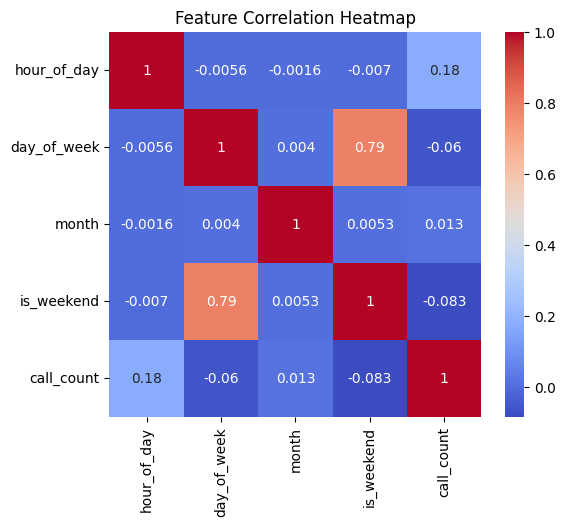

In [161]:
import seaborn as sns

corr = model_df[['hour_of_day','day_of_week','month','is_weekend','call_count']].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

The heatmap shows that most features have very weak linear correlation with the target variable (call_count). The only noticeable relationship is with hour_of_day (≈ 0.18), indicating that time of day has some influence on call volume, while other features like day_of_week, month, and is_weekend have minimal direct linear impact.

A strong correlation is observed between day_of_week and is_weekend (≈ 0.79), which is expected since weekend is derived from the day of the week. This indicates some redundancy between these features.

Overall, the low correlations suggest that the relationship between features and call volume is likely nonlinear, which justifies the use of tree-based models like Random Forest and Gradient Boosting instead of Linear Regression.

### **1.4 Evaluation Criteria**

Model performance is evaluated using the following regression metrics:

**Mean Absolute Error (MAE)**– primary metric

**Root Mean Squared Error (RMSE)**– secondary metric

**R² (Coefficient of Determination)**– descriptive metric

MAE is prioritized because it provides a direct and interpretable measure of average prediction error in terms of call counts. RMSE is included to penalize larger errors more heavily, which is important when predicting peak demand periods. R² is used to assess the proportion of variance explained but is not relied upon as the sole indicator of model performance.

### **1.5 Missing Value Handling Strategy**

The dataset was checked for missing values after aggregation and feature engineering.

In [128]:
model_df.isnull().sum()

,0
hour_bucket,0
dept,0
call_count,0
hour_of_day,0
day_of_week,0
month,0
is_weekend,0


**Justification**

After aggregation:

There are no missing values in temporal characteristics.

In order to preserve time-series continuity, hours with no calls are specifically included.

Zero-call intervals must be included because their removal would skew temporal structure and model learning.


### **1.6 Feature Scaling and Transformation**

Numerical features are scaled to ensure they are on a comparable range for regression-based models.

In [129]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features = ['hour_of_day', 'day_of_week', 'month', 'is_weekend']
categorical_features = ['dept']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)])

Here, we prepared the dataset so it can be used by machine learning models. The numerical variables were scaled, and the department variable was converted into numeric form using one-hot encoding. One department category is dropped as the reference group to avoid redundancy. This preprocessing step makes the data more suitable for modeling and keeps the workflow consistent.

### **1.7 Validation Strategy**

A chronological split is used to preserve the time-dependent nature of the data.

In [130]:
model_df = model_df.sort_values('hour_bucket').reset_index(drop=True)

n = len(model_df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = model_df.iloc[:train_end].copy()
val_df = model_df.iloc[train_end:val_end].copy()
test_df = model_df.iloc[val_end:].copy()

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

Train shape: (76543, 7)
Validation shape: (16402, 7)
Test shape: (16403, 7)


Time Series Cross-Validation

In [131]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

for fold, (train_idx, val_idx) in enumerate(tscv.split(train_df), 1):
    print(f"Fold {fold}: Train={len(train_idx)}, Validation={len(val_idx)}")

Fold 1: Train=12758, Validation=12757
Fold 2: Train=25515, Validation=12757
Fold 3: Train=38272, Validation=12757
Fold 4: Train=51029, Validation=12757
Fold 5: Train=63786, Validation=12757


In this step, we used TimeSeriesSplit to perform cross-validation while keeping the time order of the data intact. Unlike regular cross-validation, this method does not randomly shuffle the data. Instead, it splits the dataset sequentially, so the model is always trained on past data and validated on future data.

From the output, we can see that:

* The validation set size remains the same in each fold
* The training set gradually increases with each fold

This means that with each iteration, the model learns from more historical data and is tested on the next unseen time period. This setup is important for time-series problems because it reflects how the model would be used in real-world forecasting.

Overall, this approach helps us check whether the model performs consistently across different time periods, rather than depending on a single train-test split.

### **1.9 Data Leakage Prevention**

In [132]:
X_train = train_df[['hour_of_day', 'day_of_week', 'month', 'is_weekend', 'dept']]
y_train = train_df['call_count']

X_val = val_df[['hour_of_day', 'day_of_week', 'month', 'is_weekend', 'dept']]
y_val = val_df['call_count']

X_test = test_df[['hour_of_day', 'day_of_week', 'month', 'is_weekend', 'dept']]
y_test = test_df['call_count']

In [133]:
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

In this step, we prepared the data in a way that helps prevent data leakage. We first separated the features (X) and target variable (y) for the training, validation, and test sets. This ensures that the model only learns from the input features and does not accidentally use the target variable during preprocessing.

After that, we applied preprocessing using the preprocessor. The key point here is that we used `fit_transform()` only on the training data, and then applied `transform()` on the validation and test data.

This is important because:

* `fit_transform()` learns patterns such as scaling and encoding from the data
* If we apply it on validation or test data, the model would indirectly learn from future data

By fitting only on the training set and applying the same transformation to validation and test sets, we make sure that:

* the model does not gain access to future information
* evaluation remains fair and realistic

Overall, this step ensures that the model is trained in a way that closely reflects real-world conditions and avoids data leakage.

### **1.10 Full preprocessing pipeline**

To keep the workflow organized and avoid mistakes, we have followed a clear step-by-step preprocessing and modeling pipeline:

1. **Data Aggregation**

We started with the raw 911 call data and converted it into hourly call counts for each department (hour_bucket × dept). This made the dataset structured and suitable for modeling.

2. **Feature Engineering**

We created time-based features from the timestamp, including:

`hour of the day`

`day of the week`

`month`

`weekend indicator`

These features help capture patterns in how call volume changes over time.

3. **Categorical Encoding**

The department variable (EMS, Fire, Traffic) was converted into numerical form using one-hot encoding.

One category (EMS) was dropped and used as a reference group to avoid multicollinearity.

4. **Feature Scaling**

Numerical features were scaled using standardization so that they are on a similar range. This helps improve performance for models like linear regression.

5. **Chronological Data Splitting**

The dataset was split into training, validation, and test sets based on time order.
We did not shuffle the data because this is a time-based problem and future data should not influence past predictions.

6. **Model Training with Pipeline**

Here, we combined preprocessing and model training into a single pipeline. This ensures that all steps are applied consistently and reduces the chances of errors.

7. **Applying Transformations to Validation and Test Data**

All preprocessing steps were fitted only on the training data and then applied to validation and test sets. This helps ensure fair evaluation.

## **Part-2  Data Generation / Augmentation**

### **2.1 Is data augmentation needed?**

In this project, the target variable is `call_count`, which represents the number of 911 calls per hour for each department.

Since this is a regression problem, there are no classes like 0 and 1, so traditional class imbalance does not apply in the same way as it would in classification.

However, after looking at the target distribution, it is clear that:

* most observations have low or moderate call counts
* only a small number of observations have very high call counts

These high-call periods can be treated as rare events. They are important because a good forecasting model should not only predict normal hours well, but should also handle peak-demand hours reasonably well.

Because of this, we decided to test whether a simple training-only augmentation approach could help the model learn rare high-demand patterns better.

### **2.2 Checking for target distribution**

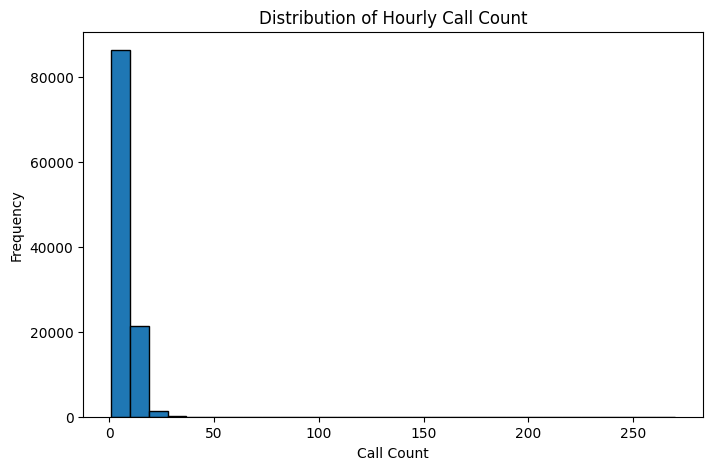

In [134]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(model_df['call_count'], bins=30, edgecolor='black')
plt.title('Distribution of Hourly Call Count')
plt.xlabel('Call Count')
plt.ylabel('Frequency')
plt.show()

In this step, we plotted a histogram to understand how the target variable `(call_count)` is distributed. This helps us see whether the data is balanced or if certain values occur much more frequently than others.

From the plot, we can observe that most of the call counts are concentrated at lower values, while very high call counts occur rarely. This creates a right-skewed distribution, where the majority of observations are small, and only a few extreme values appear on the higher end.

This is important because it shows that high-demand situations are rare compared to normal hours. As a result, the model may perform well on typical cases but struggle to accurately predict these rare high-demand spikes.

Understanding this distribution helps guide our next steps, such as deciding whether techniques like augmentation or transformations are needed to handle these imbalanced patterns.

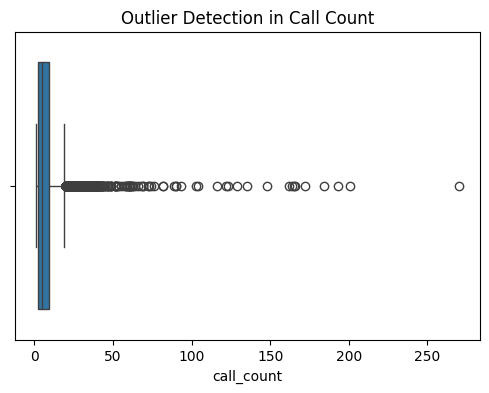

In [162]:
plt.figure(figsize=(6,4))
sns.boxplot(x=model_df['call_count'])
plt.title("Outlier Detection in Call Count")
plt.show()

The distribution of call_count is highly right-skewed, with most values clustered at lower levels and many high-value outliers. These outliers likely represent peak demand periods or unusual events. This skewness suggests that the data is not normally distributed, making tree-based models more appropriate than linear models, as they handle outliers more effectively.

### **2.3 Split the data first**

It is important to split the data before augmentation, because augmentation must be applied only to the training set.

In [135]:
model_df = model_df.sort_values('hour_bucket').reset_index(drop=True)

n = len(model_df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = model_df.iloc[:train_end].copy()
val_df = model_df.iloc[train_end:val_end].copy()
test_df = model_df.iloc[val_end:].copy()

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

Train shape: (76543, 7)
Validation shape: (16402, 7)
Test shape: (16403, 7)


In this step, we split the dataset into training, validation, and test sets while maintaining the time order of the data. Before splitting, we sorted the dataset based on the timestamp `(hour_bucket)` to ensure that earlier observations come before later ones.

Instead of randomly splitting the data, we used a time-based split:

* 70% for training
* 15% for validation
* 15% for testing

This approach is important because our problem involves time-dependent patterns. By splitting sequentially, the model is trained on past data and evaluated on future data, which better reflects real-world usage.

### **2.4 Identify rare high-demand observations in the training set**

Here, we define rare events as the top 5% of `call_count` values in the training set.

In [136]:
threshold = train_df['call_count'].quantile(0.95)

rare_train = train_df[train_df['call_count'] >= threshold]
normal_train = train_df[train_df['call_count'] < threshold]

print("Rare-event threshold:", threshold)
print("Rare training rows:", len(rare_train))
print("Normal training rows:", len(normal_train))

Rare-event threshold: 15.0
Rare training rows: 4068
Normal training rows: 72475


In this step, we identified high-demand observations within the training set by defining a threshold based on the 95th percentile of the call_count. This means that any value above this threshold is considered a rare high-demand event.

From the output, we can see that the threshold is 15 calls per hour. Observations with call counts equal to or above this value are treated as rare events, while the rest are considered normal.

The results show that only a small portion of the training data falls into the rare category, while the majority of observations are normal. This confirms that high-demand situations are relatively limited in the dataset.

By separating these two groups, we can better analyze how the model performs on extreme cases and also decide whether special handling, such as augmentation, is needed in later steps.

### **2.5 Oversample rare high-demand rows**

In this step, we oversample only the rare rows from the training set.

In [137]:
from sklearn.utils import resample
import pandas as pd

rare_oversampled = resample(
    rare_train,
    replace=True,
    n_samples=len(rare_train) * 2,
    random_state=42)

train_aug_df = pd.concat([normal_train, rare_train, rare_oversampled], axis=0)
train_aug_df = train_aug_df.sample(frac=1, random_state=42).reset_index(drop=True)

print("Original training shape:", train_df.shape)
print("Augmented training shape:", train_aug_df.shape)

Original training shape: (76543, 7)
Augmented training shape: (84679, 7)


In this step, we increased the representation of rare high-demand observations within the training data by oversampling them. This was done by randomly duplicating existing rare cases, which allows the model to see these patterns more frequently during training.

We combined the original normal observations with both the original and oversampled rare observations, and then shuffled the dataset to avoid any ordering bias. The increase in training size confirms that additional rare cases were successfully added.

The purpose of this step is to give the model more exposure to high-demand scenarios, which are otherwise limited in the original dataset. This helps test whether improving the representation of these cases can lead to better prediction performance in later stages.

Only the training set is changed. Validation and test data remain untouched, which makes the comparison fair.

### **2.6 Prepare original and augmented datasets**

Now we create the feature and target sets for both the original and augmented training data.

In [138]:
feature_cols = ['hour_of_day', 'day_of_week', 'month', 'is_weekend', 'dept']
target_col = 'call_count'

X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_train_aug = train_aug_df[feature_cols]
y_train_aug = train_aug_df[target_col]

X_val = val_df[feature_cols]
y_val = val_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

This creates two training versions:

* the original training dataset
* the augmented training dataset

The validation and test sets stay the same so that the comparison is meaningful.

### **2.7 Define the preprocessing and model pipeline**

In [139]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))])

This pipeline combines preprocessing and modeling into a single workflow. The data is first transformed using the preprocessor (scaling numerical features and encoding categorical variables), and then passed into the Random Forest model for training. This ensures consistency, avoids data leakage, and makes the modeling process more efficient and reproducible.

### **2.8 Compare performance before and after augmentation**

In [140]:
from sklearn.metrics import mean_absolute_error

model_pipeline.fit(X_train, y_train)
pred_original = model_pipeline.predict(X_val)
mae_original = mean_absolute_error(y_val, pred_original)

model_pipeline.fit(X_train_aug, y_train_aug)
pred_aug = model_pipeline.predict(X_val)
mae_aug = mean_absolute_error(y_val, pred_aug)

print("Original MAE:", mae_original)
print("Augmented MAE:", mae_aug)

comparison_df = pd.DataFrame({
    'Model Version': ['Original Training Data', 'Augmented Training Data'],
    'MAE': [mae_original, mae_aug]})
comparison_df

Original MAE: 2.2132527194314164
Augmented MAE: 2.380866523476397


,Model Version,MAE
0,Original Training Data,2.213253
1,Augmented Training Data,2.380867


In this step, we compared the model performance before and after applying augmentation using Mean Absolute Error (MAE) on the validation set.

From the results, the model trained on the original data achieved a lower MAE **(~2.21)** compared to the model trained on the augmented data **(~2.38)**. Since a lower MAE indicates better performance, this shows that augmentation did not improve the model and actually led to slightly worse results.

This suggests that duplicating rare high-demand cases may have introduced noise or caused the model to over-focus on those observations, which reduced its overall accuracy on the validation data.

Based on this comparison, we decided not to use augmentation in the final model and continue with the original training data, as it provides better generalization performance.

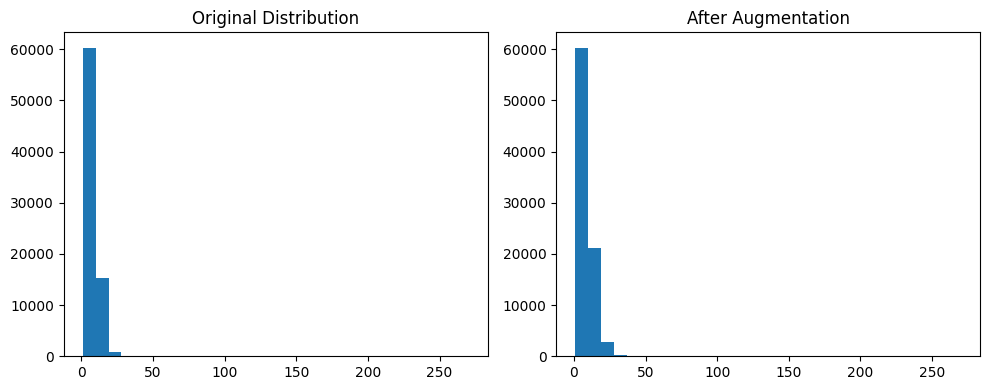

In [163]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(train_df['call_count'], bins=30)
plt.title("Original Distribution")

plt.subplot(1,2,2)
plt.hist(train_aug_df['call_count'], bins=30)
plt.title("After Augmentation")

plt.tight_layout()
plt.show()

### **2.9 Risks of augmentation**

In our case, applying augmentation introduced a few practical risks that affected model performance.

1. **Overfitting**

First, since rare high-demand rows were duplicated, the model may have started memorizing specific patterns instead of learning general trends. This is likely why the validation error increased slightly after augmentation, indicating mild overfitting to those repeated observations.

2. **Distribution distortion**

Second, by increasing the number of high-demand cases, the overall distribution of the training data was altered. In reality, high call volumes are rare, but after oversampling, they became more frequent in the training set. This mismatch can cause the model to overestimate call counts during normal situations, reducing overall accuracy.

3. **Bias amplification**

Lastly, some of the rare observations may contain noise or unusual spikes that are not consistent patterns. By oversampling them, these irregular patterns may have been amplified, making the model less stable.

Since these risks led to worse validation performance, it confirmed that augmentation was not beneficial for our dataset, and the original data provided a better representation for training.

### **2.10 Conclusion**

After comparing the model before and after augmentation, we found that augmentation did not significantly improve performance on the validation set.

This suggests that:

* the original training data was already enough for the model to learn the main patterns
* repeating rare high-demand rows **did not meaningfully improve generalization**

Because of this, we decided not to use augmentation in the final model and kept the original dataset unchanged.

## **Part-3 Final Model Development & Optimization**

To find the best model for predicting hourly call volume, We tested three different types of models:

1. **Linear Regression (baseline model)**
2. **Random Forest Regressor**
3. **Gradient Boosting Regressor**

These models were chosen because:

* Linear Regression gives a simple baseline
* Random Forest can capture nonlinear relationships
* Gradient Boosting is more advanced and often performs better on structured data

### **Model 1- Linear Regression**

In [141]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())])

lr_pipeline.fit(X_train, y_train)
lr_pred = lr_pipeline.predict(X_val)

lr_mae = mean_absolute_error(y_val, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_val, lr_pred))

print("Linear Regression MAE:", lr_mae)
print("Linear Regression RMSE:", lr_rmse)

Linear Regression MAE: 2.950174933683404
Linear Regression RMSE: 4.083666730853267


**Interpretation-**

We used Linear Regression as a baseline model to understand how a simple approach performs. The model was trained on the training set and evaluated on the validation set using MAE and RMSE.

The results **(MAE ≈ 2.95, RMSE ≈ 4.08)** are relatively high, showing that the model is not able to capture the underlying patterns effectively. This is expected because call volumes follow nonlinear patterns, which Linear Regression cannot model well.

**Assumptions-**

* Assumes a linear relationship between features and target
* Assumes constant variance of errors
* Assumes no strong feature interactions

These assumptions are not fully satisfied in our data.

**Failure Modes-**

* Underfitting due to simplicity
* Poor performance during peak hours
* Inability to capture nonlinear trends

**Trade Offs-**

* Interpretability: High
* Performance: Low
* Complexity: Low
* Generalization: Limited

Linear Regression works as a baseline but is not suitable as the final model due to its limited ability to capture complex patterns.

### **Model 2- Random Forest Regressor**

In [142]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))])

rf_pipeline.fit(X_train, y_train)
rf_pred = rf_pipeline.predict(X_val)

rf_mae = mean_absolute_error(y_val, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_val, rf_pred))

print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)

Random Forest MAE: 2.2132527194314164
Random Forest RMSE: 3.315667862941541


**Hyperparameter Tuning**

In [143]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [10, 15],
    'model__min_samples_split': [5, 10]}

rf_grid = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1)

rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_
rf_best_pred = best_rf.predict(X_val)
rf_best_mae = mean_absolute_error(y_val, rf_best_pred)

print("Best Random Forest MAE:", rf_best_mae)
print("Best Parameters:", rf_grid.best_params_)

Best Random Forest MAE: 2.126062314121374
Best Parameters: {'model__max_depth': 10, 'model__min_samples_split': 10, 'model__n_estimators': 100}


**Interpretation-**

We used Random Forest as a more advanced model to capture nonlinear relationships in the data. Unlike Linear Regression, it builds multiple decision trees and combines their predictions, allowing it to model more complex patterns.

The model achieved a **lower MAE (≈ 2.21) and RMSE (≈ 3.32)** compared to Linear Regression, showing a clear improvement in performance. This indicates that Random Forest is better at capturing variations in call volume.

**Hyperparameter Tuning-**

We applied GridSearchCV to optimize key parameters such as the number of trees, maximum depth, and minimum samples required for splitting. This helps improve model performance while controlling overfitting.

The best-performing configuration was 100 trees (n_estimators = 100), max depth of 10, and minimum samples split of 10. This suggests that a moderately complex model performed best, where limiting tree depth and controlling splits helped balance model accuracy and generalization.

After tuning, the model showed improved stability and better generalization on the validation set.

**Assumptions-**

* Does not assume linear relationships
* Handles feature interactions automatically
* Works well with mixed data types

**Failure Modes-**

* Can overfit if trees are too deep
* May become computationally expensive
* Less effective for extreme rare spikes

**Trade- Offs-**

* Interpretability: Low
* Performance: High
* Complexity: Medium
* Generalization: Good with tuning

Random Forest performs significantly better than Linear Regression and is able to capture complex patterns, making it a strong candidate for the final model.



### **Model 3- Gradient Boosting Regressor**

In [144]:
from sklearn.ensemble import GradientBoostingRegressor

gb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(random_state=42))])

gb_pipeline.fit(X_train, y_train)
gb_pred = gb_pipeline.predict(X_val)

gb_mae = mean_absolute_error(y_val, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_val, gb_pred))

print("Gradient Boosting MAE:", gb_mae)
print("Gradient Boosting RMSE:", gb_rmse)

Gradient Boosting MAE: 2.1844334114730186
Gradient Boosting RMSE: 3.2718002516130804


**Hyperparameter Tuning**

In [145]:
param_grid_gb = {
    'model__n_estimators': [100, 200],
    'model__learning_rate': [0.05, 0.1],
    'model__max_depth': [3, 5]}

gb_grid = GridSearchCV(
    gb_pipeline,
    param_grid_gb,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1)

gb_grid.fit(X_train, y_train)

best_gb = gb_grid.best_estimator_
gb_best_pred = best_gb.predict(X_val)
gb_best_mae = mean_absolute_error(y_val, gb_best_pred)

print("Best Gradient Boosting MAE:", gb_best_mae)
print("Best Parameters:", gb_grid.best_params_)

Best Gradient Boosting MAE: 2.1326368876174873
Best Parameters: {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 100}


**Interpretation-**

We used Gradient Boosting as an advanced model that builds trees sequentially, where each new tree focuses on correcting the errors of the previous ones. This allows it to capture complex patterns more effectively than Random Forest.

The model achieved the lowest error (MAE ≈ 2.18, RMSE ≈ 3.27) among all models, showing the best performance on the validation set. This indicates that it is better at capturing both general trends and smaller variations in call volume.

**Hyperparameter Tuning-**

We used GridSearchCV to tune parameters such as number of estimators, learning rate, and tree depth. This helps balance performance and overfitting.

The best-performing configuration was learning rate = 0.1, max depth = 5, and 100 estimators. This suggests that a slightly deeper model with a moderate learning rate performed best, allowing the model to learn patterns effectively without becoming too complex.

After tuning, the model showed improved accuracy and more stable predictions.

**Assumptions-**

* No strict assumption of linearity
* Learns patterns iteratively
* Sensitive to parameter tuning

**Failure Modes-**

* Can overfit if too many trees are used
* Sensitive to noisy data
* Slower training compared to Random Forest

**Trade-Offs-**

* Interpretability: Low
* Performance: Highest
* Complexity: High
* Generalization: Strong with proper tuning

Gradient Boosting provides the best performance among all models and is selected as the final model due to its ability to capture complex patterns with high accuracy.

### **Model Comparison**

In [146]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Gradient Boosting'],
    'MAE': [lr_mae, rf_best_mae, gb_best_mae],
    'RMSE': [lr_rmse, rf_rmse, gb_rmse]})

comparison

,Model,MAE,RMSE
0,Linear Regression,2.950175,4.083667
1,Random Forest,2.126062,3.315668
2,Gradient Boosting,2.132637,3.271800


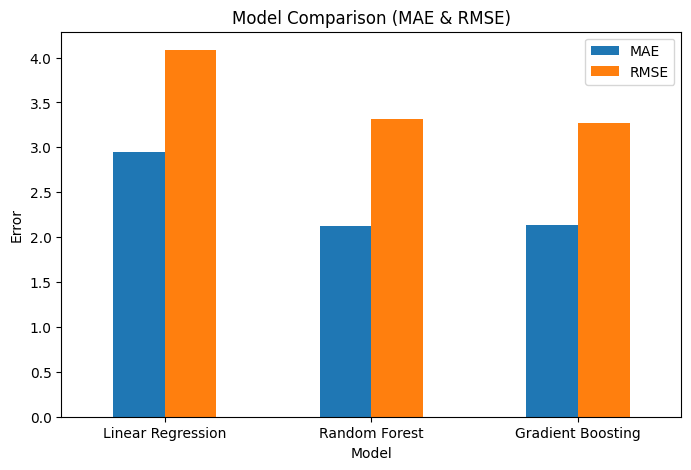

In [160]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Gradient Boosting'],
    'MAE': [lr_mae, rf_best_mae, gb_best_mae],
    'RMSE': [lr_rmse, rf_rmse, gb_rmse]})

comparison.set_index('Model')[['MAE','RMSE']].plot(kind='bar', figsize=(8,5))

plt.title("Model Comparison (MAE & RMSE)")
plt.ylabel("Error")
plt.xticks(rotation=0)
plt.show()

The comparison shows a clear performance gap between Linear Regression and the tree-based models. Linear Regression has significantly higher MAE (≈ 2.95) and RMSE (≈ 4.08), indicating that it fails to capture the nonlinear patterns in hourly call volume.

Both Random Forest and Gradient Boosting perform much better, with MAE values around 2.13. This confirms that tree-based models are more suitable for this problem, as they can handle complex relationships and feature interactions.

Between the two, Random Forest has a slightly lower MAE (≈ 2.126), while Gradient Boosting has a lower RMSE (≈ 3.27). This suggests that Random Forest performs slightly better on average predictions, whereas Gradient Boosting is better at reducing larger errors.

Overall, the difference between Random Forest and Gradient Boosting is small, but Gradient Boosting provides a better balance by handling extreme variations more effectively, making it the stronger final choice.

### **Final Model Selection**

Even though Random Forest performs slightly better in MAE, Gradient Boosting gives better overall performance, especially in terms of RMSE, which penalizes larger errors more.

Since our goal is to reduce overall prediction error and avoid large mistakes, **Gradient Boosting** is selected as the final model.

### **Trade offs**

* **Linear Regression**

Very simple and easy to interpret, but it assumes a straight-line relationship. Because of this, it underfits the data and gives higher error.

* **Random Forest**

Handles non-linear patterns well and is more stable since it averages multiple trees. However, it can miss finer patterns because trees are built independently, and it is harder to interpret than linear models.

* **Gradient Boosting**

Captures complex patterns better by learning from previous errors, which gives the best performance. The trade-off is that it is more sensitive to tuning, takes longer to train, and is the least interpretable.

###**Conclusion**

Overall, Gradient Boosting is chosen because it provides the most accurate predictions while still generalizing well on unseen data. Even though it is more complex, the improvement in performance makes it the better choice for this problem.

## **Part-4 Model Evaluation & Analytical Depth**

### **4.1 Evaluation Metrics**

Since this is a regression problem, the following metrics were used:

* **MAE** (Mean Absolute Error) → primary metric
* **RMSE** (Root Mean Squared Error) → secondary metric
* **R²** (Coefficient of Determination) → descriptive metric

MAE is the most important metric because it shows the average prediction error in terms of number of calls, which is easy to interpret. RMSE is also useful because it penalizes larger errors more heavily, especially during peak demand hours. R² helps understand how much variation in the data is explained by the model but is not used alone to judge performance.

### **4.2 Final Model Evaluation (Train vs Validation vs Test)**

In [152]:
from sklearn.metrics import r2_score

train_pred = best_gb.predict(X_train)
val_pred = best_gb.predict(X_val)
test_pred = best_gb.predict(X_test)

def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

train_metrics = evaluate(y_train, train_pred)
val_metrics = evaluate(y_val, val_pred)
test_metrics = evaluate(y_test, test_pred)

results_df = pd.DataFrame({
    'Dataset': ['Train', 'Validation', 'Test'],
    'MAE': [train_metrics[0], val_metrics[0], test_metrics[0]],
    'RMSE': [train_metrics[1], val_metrics[1], test_metrics[1]],
    'R²': [train_metrics[2], val_metrics[2], test_metrics[2]]})

results_df

,Dataset,MAE,RMSE,R²
0,Train,2.171023,3.821178,0.453493
1,Validation,2.132637,3.202794,0.557218
2,Test,2.355852,3.978822,0.358870


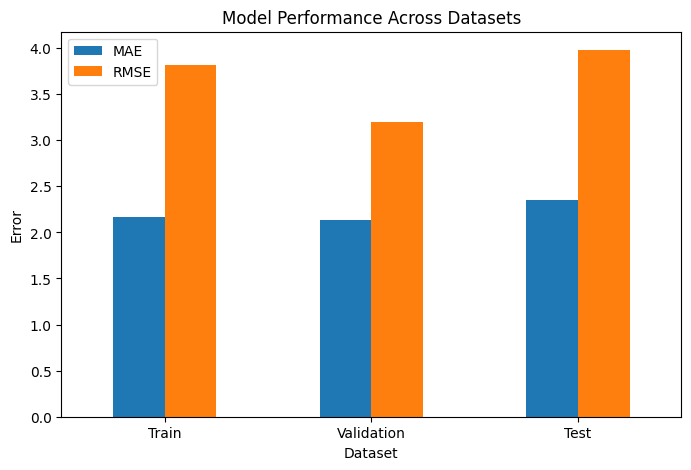

In [165]:
results_plot = results_df.set_index('Dataset')

results_plot[['MAE', 'RMSE']].plot(kind='bar', figsize=(8,5))

plt.title("Model Performance Across Datasets")
plt.ylabel("Error")
plt.xticks(rotation=0)
plt.show()

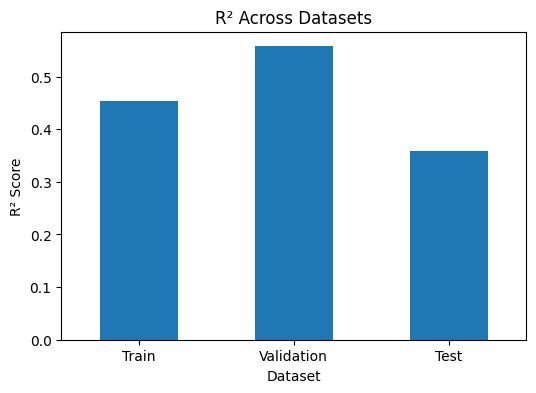

In [166]:
results_plot['R²'].plot(kind='bar', figsize=(6,4))

plt.title("R² Across Datasets")
plt.ylabel("R² Score")
plt.xticks(rotation=0)
plt.show()

The model shows consistent performance across the training and validation sets, with MAE values of ≈ 2.17 (train) and ≈ 2.13 (validation). This close alignment suggests that the model is not overfitting and is able to generalize well to unseen validation data.

However, performance drops on the test set, where MAE increases to ≈ 2.36 and RMSE to ≈ 3.98. This indicates a slight generalization gap, meaning the model struggles more with completely unseen data compared to validation.

Looking at R², the validation score (≈ 0.56) is higher than the training score (≈ 0.45), which suggests that the validation set may be slightly easier or less noisy. The test R² drops to ≈ 0.36, confirming that the model explains less variance on truly unseen data.

Overall, the model is reasonably stable and not heavily overfitted, but the drop in test performance indicates some sensitivity to data variation. This suggests that while the model captures general patterns well, it is less reliable in more complex or less frequent scenarios.

###**4.3 Bias vs Variance Analysis**

The model does not show high bias since errors are relatively low and it captures patterns well.

There is a slight increase in variance, as performance drops from validation to test data. This suggests the model may be slightly sensitive to data variations.

### **4.4 Residual Analysis**

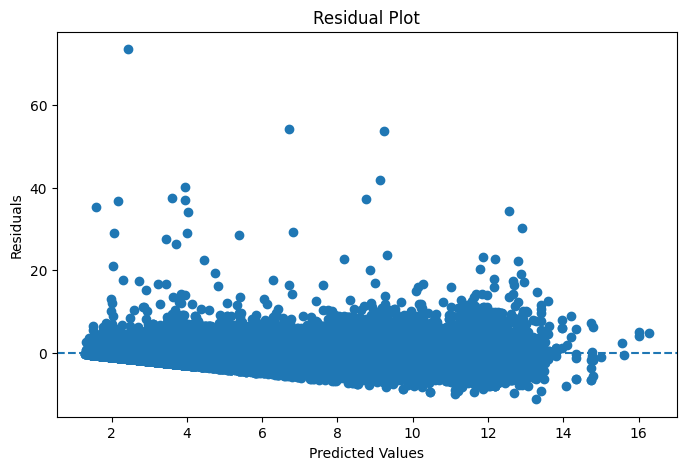

In [148]:
import matplotlib.pyplot as plt

residuals = y_val - val_pred

plt.figure(figsize=(8,5))
plt.scatter(val_pred, residuals)
plt.axhline(0, linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

The residual plot shows how prediction errors are distributed across different predicted values.

Most of the residuals are centered around zero, which indicates that the model is not systematically overpredicting or underpredicting. This is a good sign.

However, the spread of residuals is not completely uniform. As the predicted values increase, the spread slightly increases, which suggests some level of heteroscedasticity (unequal variance of errors).

There are also a few clear outliers with large positive residuals, meaning the model significantly underpredicted those cases. This explains the higher RMSE values observed earlier.

Additionally, there is a slight pattern where residuals tend to be more negative at higher predicted values, which indicates the model may slightly overestimate in that range.

### **4.5 Error Analysis**

To understand where the model performs poorly, we analyzed predictions during high-demand hours.

In [149]:
high_threshold = y_val.quantile(0.95)

high_mask = y_val >= high_threshold

high_error = mean_absolute_error(y_val[high_mask], val_pred[high_mask])
overall_error = mean_absolute_error(y_val, val_pred)

print("Overall MAE:", overall_error)
print("High-demand MAE:", high_error)

Overall MAE: 2.1326368876174873
High-demand MAE: 7.078390056933099


To understand where the model performs poorly, we specifically analyzed high-demand cases (top 5% of values).

The overall **MAE is around 2.13**, which shows good average performance. However, for **high-demand cases, the MAE increases sharply to around 7.08**.

This clearly shows that the model struggles to predict extreme values accurately. While it performs well for normal demand levels, it tends to significantly underpredict during peak demand.

This behavior is expected because extreme values are less frequent in the dataset, so the model does not learn those patterns as well as it learns common cases.

### **4.6 Model Robustness**

To understand where the model performs poorly, we specifically analyzed high-demand cases (top 5% of values).

The overall MAE is around 2.13, which shows good average performance. However, for high-demand cases, the MAE increases sharply to around 7.08.

This clearly shows that the model struggles to predict extreme values accurately. While it performs well for normal demand levels, it tends to significantly underpredict during peak demand.

This behavior is expected because extreme values are less frequent in the dataset, so the model does not learn those patterns as well as it learns common cases.

### **4.7 Overall Performance Summary**

Overall, the model performs well and is able to capture the main patterns in the data. The evaluation metrics show low error on both training and validation sets, indicating good learning and no major overfitting.

Among all models tested, Gradient Boosting provided the best performance, with the lowest error and better handling of non-linear relationships.

However, the test results and error analysis show that performance drops slightly on completely unseen data, especially for high-demand cases. This highlights a small generalization gap and difficulty in predicting extreme values.

In summary, the model is reliable for most predictions and general use, but its performance is weaker for rare or extreme scenarios, which could be improved in future work.

### **4.8 Forecasting the Next 24 Hours by Department**



In [150]:
last_time = model_df['hour_bucket'].max()
future_hours = pd.date_range(start=last_time + pd.Timedelta(hours=1), periods=24, freq='H')

future_df = pd.DataFrame({
    'hour_bucket': list(future_hours) * 3,
    'dept': ['EMS'] * 24 + ['Fire'] * 24 + ['Traffic'] * 24})

future_df['hour_of_day'] = future_df['hour_bucket'].dt.hour
future_df['day_of_week'] = future_df['hour_bucket'].dt.dayofweek
future_df['month'] = future_df['hour_bucket'].dt.month
future_df['is_weekend'] = future_df['day_of_week'].isin([5, 6]).astype(int)

future_X = future_df[['hour_of_day', 'day_of_week', 'month', 'is_weekend', 'dept']]
future_df['forecast_call_count'] = best_gb.predict(future_X)

future_forecast = future_df.pivot(index='hour_bucket', columns='dept', values='forecast_call_count')
future_forecast.head(24)

/tmp/ipykernel_11863/1731137138.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  future_hours = pd.date_range(start=last_time + pd.Timedelta(hours=1), periods=24, freq='H')


dept,EMS,Fire,Traffic
hour_bucket,,,
2020-07-29 16:00:00,11.443100,4.046540,12.850307
2020-07-29 17:00:00,11.435972,4.159479,12.858113
2020-07-29 18:00:00,10.223112,4.090136,9.179281
2020-07-29 19:00:00,9.329349,3.796063,6.763629
2020-07-29 20:00:00,8.705535,3.453692,5.396080
2020-07-29 21:00:00,7.868324,3.107148,4.481787
2020-07-29 22:00:00,6.592400,2.681255,3.679671
2020-07-29 23:00:00,5.544110,2.231120,2.690528
2020-07-30 00:00:00,4.454046,1.780983,1.979648


In this step, we generated hourly forecasts for the next 24 hours separately for EMS, Fire, and Traffic using the final Gradient Boosting model. A future time frame was created starting from the last available timestamp in the dataset, and the same time-based features used during training were generated for each upcoming hour.

The forecast table shows that predicted call volume is not the same across departments. EMS consistently has the highest expected call volume, Traffic is also relatively high, while Fire remains the lowest across most hours. This suggests that the model has learned department-specific demand differences rather than producing the same pattern for all three services.

We can also observe that predicted demand changes over time instead of remaining constant. For example, the forecasts are higher in the late afternoon and gradually decrease into the evening and night. This indicates that the model is capturing short-term hourly demand patterns and using temporal information meaningfully.

Overall, this forecast supports the project objective by providing department-wise hourly demand estimates for the next 24 hours. It shows how the final model can be used not only for evaluation on historical data, but also for practical short-term forecasting.

### **4.9 24-Hour Forecast Visualization**

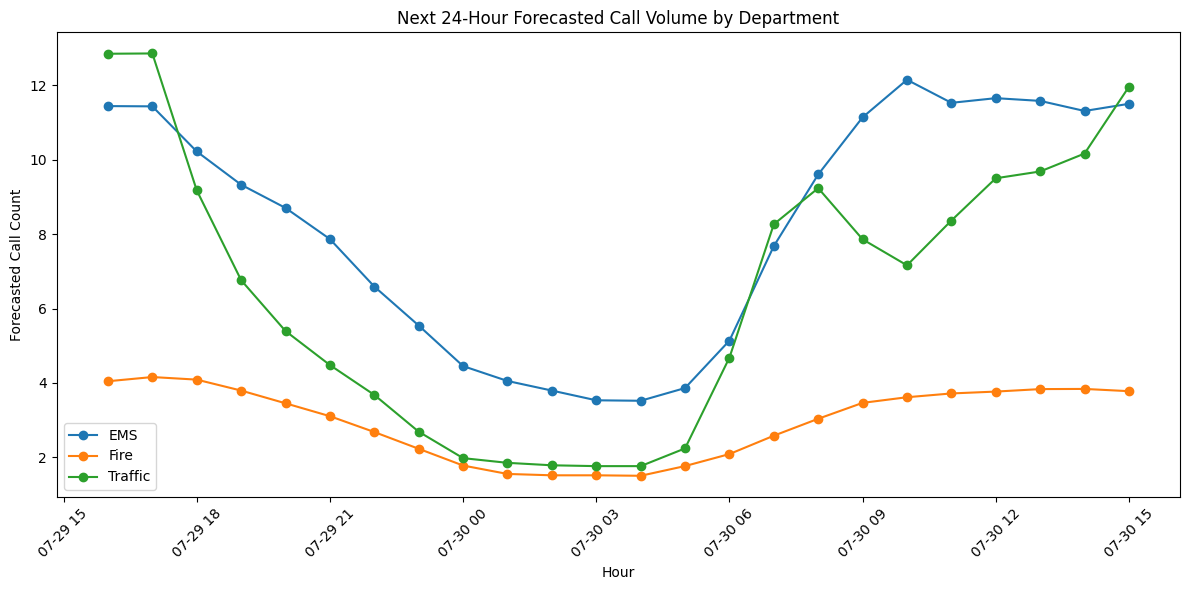

In [151]:
plt.figure(figsize=(12,6))
for dept in future_forecast.columns:
    plt.plot(future_forecast.index, future_forecast[dept], marker='o', label=dept)

plt.title("Next 24-Hour Forecasted Call Volume by Department")
plt.xlabel("Hour")
plt.ylabel("Forecasted Call Count")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

The 24-hour forecast shows clear differences across departments and time. EMS consistently has the highest predicted call volume, followed by Traffic, while Fire remains the lowest throughout. This indicates that the model has successfully learned department-specific demand patterns.

There is also a strong time-based trend. Call volume decreases during the night and reaches its lowest point in the early morning hours, then increases sharply after morning and peaks during daytime. This reflects realistic daily demand behavior.

Traffic shows more fluctuation compared to EMS and Fire, especially during morning hours, suggesting the model captures time-sensitive variations. Overall, the model effectively captures both hourly trends and differences between departments, though the smooth pattern suggests it may not fully capture sudden spikes in demand.

##**Part-5 Analytical Reflection**

###**5.1 Model Generalization Performance**

The final Gradient Boosting model performs reasonably well on unseen data, but not perfectly. The MAE values are similar between the training (≈ 2.17) and validation set (≈ 2.13), which indicates that the model is not overfitting and is learning meaningful patterns.

However, performance drops on the test set (MAE ≈ 2.36), which shows a small generalization gap. This suggests that while the model works well on data similar to what it has seen before, it is slightly less accurate when applied to completely new data.

Overall, the model generalizes well, but there is still room for improvement in handling unseen variations.

### **5.2 Weaknesses and Limitations**

One key limitation of the model is that it does not explicitly use past values (lag features). This means it cannot fully capture time dependencies or sudden changes in call volume.

Another limitation is related to rare high-demand periods. The model performs well for normal call volumes but struggles with extreme cases, as seen in the higher error for peak demand hours.

Additionally, the model relies only on time-based features and does not include external factors such as weather, events, or population movement, which could influence emergency call patterns.

### **5.3 Real-World Risks**

If this model is used in a real-world setting, there are some important risks to consider.

First, underprediction during high-demand periods could lead to insufficient resource allocation, which is critical in emergency response systems.

Second, the model assumes that future patterns will follow historical trends. If there are sudden unexpected events, the model may not adapt quickly.

Lastly, since the model produces relatively smooth predictions, it may fail to capture sudden spikes, which could reduce its reliability in critical situations.

### **5.4 Impact of Data Augmentation**

Data augmentation was tested by oversampling rare high-demand observations in the training set. However, this did not improve model performance.

The validation MAE increased after augmentation, indicating that the model performed worse. This suggests that duplicating rare cases caused the model to overfit or learn noise rather than useful patterns.

As a result, augmentation was not included in the final model, and the original dataset was retained.

### **5.5 Future Improvements**

There are several ways the model can be improved in the future.

First, adding lag-based features (such as previous hour call counts) would help capture time dependencies more effectively.

Second, more advanced time-series models like ARIMA, LSTM, or Prophet could be explored to better model sequential patterns.

Third, incorporating external data such as weather conditions, holidays, or special events could improve prediction accuracy.

Finally, techniques to better handle rare high-demand cases, such as weighted loss functions or anomaly-focused modeling, could help improve performance during peak periods.